In [1]:
# python libs
import glob
import os

# data libs
import pandas as pd
import torch

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

from IPython.display import display, clear_output

from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.manifold import TSNE
import matplotlib as mpl

In [4]:
from Bio.Seq import Seq
from Bio import SeqIO

In [5]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Protein language model-based predictions

Reformatting ESM2 code to use the entire OGT dataset model

1. Extract ESM2 embeddings
2. Make linear model

In [6]:
# class ESMEmbeddedDataset:

#     def __init__(self, outdir : str):
#         self.base_path = outdir
#         # define location of individual embeddings
#         self.embedding_loc = os.path.abspath(outdir)
        
#         # get the list of .pt files
#         file_paths = glob.glob(os.path.join(f'{self.embedding_loc}', 'esm_outputs', '*.pt'))
        
#         # loop through each file and process
#         self.proteins = [EmbeddedProtein(file_path) for file_path in file_paths]

#     def get_protein(self, query):
#         return [p for p in self.proteins if p.label == query]
    
#     def to_dataframe(self, which='embeddings', layer=6):
#         '''
#         Return desired internal data as dataframe
#         '''
#         vals = ['full_embeddings', 'mean_embeddings', 'logits']
#         if not which in vals:
#             raise ValueError(f'which arg must be one of {", ".join(vals)} ')
        
#         # need to add more code here
#         if which ==  'mean_embeddings':
#             return pd.DataFrame(dict((t.label, 
#                            t.mean_rep[layer].detach().numpy().flatten().tolist()) for t in self.proteins)).T
                
#         elif which ==  'full_embeddings':
#             return pd.DataFrame(dict((t.label, 
#                            t.per_token_rep[layer].detach().numpy().flatten().tolist()) for t in self.proteins)).T
        
#         elif which ==  'logits':
#             return pd.DataFrame(dict((t.label, 
#                            t.logits.detach().numpy().flatten().tolist()) for t in self.proteins)).T
#         else:
#             ''
#             # this is all I'm implementing right now
#             # not sure if it's even possible to return attentions as a pandas dataframe

# class EmbeddedProtein:

#     def __init__(self, pt_path):
#         dataload = torch.load(pt_path)

#         self.path = pt_path
        
#         self.label = dataload['label']
#         self.model_info = dataload['model_info']
#         self.logits = dataload['logits']
#         self.sequence = dataload['sequence']

#         if 'attentions' in dataload.keys():
#             self.attentions = dataload['attentions']
#         if 'contacts' in dataload.keys():
#             self.attentions = dataload['contacts']
#         if 'mean_representations' in dataload.keys():
#             self.mean_rep = dataload['mean_representations']
#         if 'representations' in dataload.keys():
#             self.per_token_rep = dataload['representations']
        
#     def set_seq(self, seq):
#         self.sequence = seq
        
#     def get_seq(self):
#         return self.sequence
    
#     def get_embedding(self, layer=6):
#         return self.per_token_rep[layer].detach().numpy()

In [7]:
# %%time
# dataset = ESMEmbeddedDataset('./../data/proclam/esm2_t12_35M_UR50D/')
# dataset.proteins = [p for p in dataset.proteins if len(p.sequence) < 250]

CPU times: user 4.93 s, sys: 5.51 s, total: 10.4 s
Wall time: 13.4 s


## Get embedding for each protein

In [44]:
with open('./../data/20240122_all_adks_filtered_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

aln_df = pd.concat(lines, axis=1).T

def translate_with_gaps(nuc_seq):
    return [
        str(Seq(codon).translate()) if '-' not in codon and len(codon) == 3 else '-'
        for codon in [nuc_seq[i:i+3] for i in range(0, len(nuc_seq), 3)]
    ]

# aln_df = pd.concat([aln_df, anc_trim_df]).fillna('-')

aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,-,M,-,N,I,I,L,L,G,P,...,L,D,N,-,-,-,-,-,-,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,M,M,-,G,I,V,M,L,G,A,...,L,L,-,-,-,-,-,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,-,M,-,R,L,I,L,L,G,A,...,L,G,-,-,-,R,-,-,-,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,-,M,-,R,L,L,I,M,G,P,...,L,T,K,-,-,-,-,-,-,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,G,-,-,A,I,L,I,L,G,A,...,L,E,Y,-,L,L,E,K,-,-


In [45]:
from esm import pretrained
from esm.data import BatchConverter

In [46]:
# Load model and alphabet
model, alphabet = pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

ESM2(
  (embed_tokens): Embedding(33, 320, padding_idx=1)
  (layers): ModuleList(
    (0-5): 6 x TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=320, out_features=320, bias=True)
        (v_proj): Linear(in_features=320, out_features=320, bias=True)
        (q_proj): Linear(in_features=320, out_features=320, bias=True)
        (out_proj): Linear(in_features=320, out_features=320, bias=True)
        (rot_emb): RotaryEmbedding()
      )
      (self_attn_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=320, out_features=1280, bias=True)
      (fc2): Linear(in_features=1280, out_features=320, bias=True)
      (final_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
  )
  (contact_head): ContactPredictionHead(
    (regression): Linear(in_features=120, out_features=1, bias=True)
    (activation): Sigmoid()
  )
  (emb_layer_norm_after): LayerNorm((320,), eps=1e-05, elementwis

In [49]:
data = []
# for each protein
for index, row in aln_df.iterrows():
    seq = ''.join([s for s in row.values if s != '-'])

    # Clean sequence to ensure valid AAs only
    VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
    clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
    
    if len(seq) == len(clean_seq):
        # Batch convert
        data.append((index, clean_seq))
    else:
        print('Uh oh, invalid AA!')
        
    # print(len(protein.sequence), len(seq), protein.get_embedding(layer=12).shape)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [51]:
%%time
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
# per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 23min 57s, sys: 34min 43s, total: 58min 40s
Wall time: 4min 24s


In [62]:
aln_df = aln_df.reindex(index=labels)

In [63]:
def get_residue_loc(row, col, base=0):
    '''
    given an aligned protein (with gaps) as Series
    get the residue number of the requested column in the protein
    (i.e. the original index of the residue)
    '''
    
    # make sure it's not a gap
    if row.loc[col] == '-':
        raise KeyError('Desired col is a gap in this sequence')

    # base must be zero or one
    assert base in [0, 1]
    
    loc = row.index.get_loc(col)
    row_slice = row.iloc[:loc+1]
    _str = ''.join(row_slice[row_slice.eq('-')].astype(str))
    
    return len(_str) + base

In [64]:
col_datasets = {}
# for each column in the alignment
for col in aln_df.columns:
    # get proteins which have a residue (not a gap) at this col
    rows = aln_df[~aln_df[col].eq('-')].index
    col_str = f'{len(rows)} rows available for col {col}'

    # get the rows
    subset = aln_df.loc[rows, :]
    # get which residue this corresponds to in each protein, zero-indexed
    indeces = subset.apply(lambda row: get_residue_loc(row, col=col, base=0), axis=1)

    # for each protein
    temp_list = []
    for j, (index, item) in enumerate(indeces.items()):
        
        # progress bar
        if j % 100 == 0:
            progress_str = '#' * int((j / len(indeces)) * 20)
            fill_str = '-' * (20-len(progress_str))
            print(col_str + f' |{progress_str}{fill_str}|     ', end='\r')

        # get the embedding for that site in that protein
        ploc_in_reps = labels.index(index)
        tensor = pd.Series(data=reps.detach()[ploc_in_reps, item+1, :].numpy(), name=index)
        temp_list.append(tensor)
        
    col_datasets[col] = pd.concat(temp_list, axis=1)

In [65]:
with open('./../data/proclam/esm2_t6_8M_UR50D//per_site_data.pickle', 'wb') as handle:
    pickle.dump(col_datasets, handle)

## Build regression
### 20% randomly withheld

In [66]:
y = pd.Series(index=[i for i in aln_df.index],
          data=[float(i.split('|')[3].split('temp=')[-1]) for i in aln_df.index])

In [67]:
y_train, y_test = train_test_split(y, test_size=0.2)

In [68]:
col_datasets[0].loc[:, col_datasets[0].columns.isin(y_train.index)]

,JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,WFIX01000179.1_32|GB_GCA_009745985.1|adk|temp=30.0|bitscore=161.4,JABEEB010000001.1_1243|GB_GCA_012999515.1|adk|temp=30.0|bitscore=184.6,LR632930.1_667|GB_GCA_902167325.1|adk|temp=22.0|bitscore=182.2,NC_013939.1_1742|RS_GCF_000010985.1|adk|temp=62.0|bitscore=198.3,NC_005861.2_1007|RS_GCF_000011565.2|adk|temp=25.0|bitscore=166.5,NC_007204.1_1598|RS_GCF_000012305.1|adk|temp=20.0|bitscore=181.2,NC_007517.1_654|RS_GCF_000012925.1|adk|temp=30.0|bitscore=174.6,NC_008048.1_2822|RS_GCF_000013985.1|adk|temp=28.0|bitscore=166.1,...,NZ_LR134477.1_2853|RS_GCF_900637975.1|adk|temp=37.0|bitscore=164.5,NZ_CABJCG010000010.1_201|RS_GCF_902364025.1|adk|temp=37.0|bitscore=197.7,NZ_LR699119.1_1130|RS_GCF_902459485.1|adk|temp=37.0|bitscore=179.4,NZ_CAJGYT010000001.1_1984|RS_GCF_904846035.1|adk|temp=30.0|bitscore=179.9,NZ_CAJGZP010000001.1_2133|RS_GCF_904846155.1|adk|temp=25.0|bitscore=179.5,NZ_CAJHAF010000001.1_107|RS_GCF_904846315.1|adk|temp=30.0|bitscore=185.3,NZ_CAJHAJ010000001.1_158|RS_GCF_904846345.1|adk|temp=25.0|bitscore=183.1,NZ_CAJHBQ010000003.1_114|RS_GCF_904846685.1|adk|temp=25.0|bitscore=185.8,NZ_CAJHBU010000016.1_37|RS_GCF_904846715.1|adk|temp=22.0|bitscore=182.5,NZ_CAJVAS010000038.1_22|RS_GCF_910593845.1|adk|temp=30.0|bitscore=190.8
0,0.650326,0.456542,0.648603,0.734725,0.295253,0.575496,0.473574,0.592185,0.658818,0.326514,...,0.520034,0.310411,0.501748,0.602222,0.575166,0.589417,0.602319,0.650475,0.581350,0.615925
1,0.332858,-0.083124,0.245909,0.100363,0.067408,0.328295,0.222793,0.363631,0.307027,0.363869,...,0.263725,-0.028866,0.259540,0.340741,0.352416,0.311354,0.357107,0.338045,0.348566,0.352935
2,-0.213717,0.147916,-0.434936,-0.529649,-0.416496,-0.551042,-0.497490,-0.363147,-0.404449,-0.568890,...,-0.427933,-0.688318,-0.489451,-0.387020,-0.349707,-0.351096,-0.378571,-0.367387,-0.363462,-0.470163
3,0.578396,0.457086,0.456384,0.447337,0.387059,0.551235,0.458130,0.474382,0.474459,0.262372,...,0.454652,0.317187,0.592817,0.392897,0.497638,0.448290,0.485182,0.461051,0.487250,0.546495
4,0.132810,0.378546,0.051383,0.233403,0.120773,0.281862,0.297767,0.252723,0.174381,0.217098,...,0.228440,0.299127,0.249434,0.230060,0.229336,0.205247,0.242803,0.270766,0.241706,0.189405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,-0.543840,-0.229950,-0.441349,-0.314701,-0.392366,-0.324548,-0.425709,-0.501730,-0.533229,-0.308478,...,-0.457269,-0.392408,-0.522378,-0.504097,-0.504170,-0.486921,-0.496579,-0.456229,-0.535613,-0.432036
316,-0.038566,-0.125974,0.064842,0.003096,-0.282205,-0.107688,-0.107455,0.032894,-0.042189,0.038956,...,0.035575,-0.304224,-0.064124,0.031104,0.030331,-0.019030,0.017337,0.032854,-0.001672,-0.051453
317,1.306352,1.289078,1.367308,1.276828,1.226686,1.177166,1.265854,1.261180,1.251489,1.476449,...,1.349544,1.389539,1.140944,1.285463,1.293932,1.290670,1.281285,1.261824,1.269636,1.157717
318,0.461485,0.439410,-0.006577,0.210406,-0.035333,0.399814,0.334831,0.205711,0.234788,0.456723,...,0.189969,0.607113,0.109952,0.201521,0.196371,0.182051,0.198524,0.219751,0.197278,0.323638


In [69]:
def compute_gaussian_weights(_y):
    # Normalize the target variable to compute KDE
    scaler = StandardScaler()
    y_scaled = scaler.fit_transform(_y.values.reshape(-1, 1))
    
    # Estimate density of target variable using KDE
    kde = KernelDensity(kernel='gaussian', bandwidth=0.4)
    kde.fit(y_scaled)
    log_density = kde.score_samples(y_scaled)
    density = np.exp(log_density)
    
    # Compute weights as inverse of density
    weights = 1 / density

    return weights

In [76]:
models = {}
metrics = pd.DataFrame(columns=['mse', 'sp_r', 'n_train', 'n_test'])
curr_best = 0
test_data = []
train_data = []

for col, col_data in list(col_datasets.items()):
    display(col)
    clear_output(wait=True)
    
    # subset_y = col_data[col_data.columns.isin(y_train.index)].index
    subset_train = col_data.reindex(columns=y_train.index).dropna(axis=1).T
    subset_test = col_data.reindex(columns=y_test.index).dropna(axis=1).T

    weights = compute_gaussian_weights(y_train.loc[subset_train.index])

    model = LinearRegression()
    model.fit(subset_train, y_train.loc[subset_train.index], sample_weight=weights)
    models[col] = model

    test_pred = model.predict(subset_test)
    test_actual = y_test.loc[subset_test.index]

    sp_r = spearmanr(test_pred, test_actual)[0]
    mse = mean_squared_error(test_pred, test_actual)
    
    metrics.loc[col, 'mse'] = mse
    metrics.loc[col, 'sp_r'] = sp_r
    metrics.loc[col, 'n_train'] = len(subset_train)
    metrics.loc[col, 'n_test'] = len(subset_test)

    train_data.append( subset_train)
    test_data.append( subset_test)

    if sp_r > curr_best:
        clear_output(wait=True)
        print('New best: ', sp_r)
        fig, ax = plt.subplots(figsize=(6,6))
        sns.scatterplot(x=test_actual, y=test_pred)

        plt.plot([10, 70], [10, 70], color='r', linestyle='--')
        
        ax.set_aspect('equal')
        sns.despine()
        ax.set_ylabel('Pred')
        ax.set_xlabel('Actual')
        ax.set_title(col)
        plt.show()

        curr_best = sp_r
    

236

<Axes: xlabel='sp_r', ylabel='Count'>

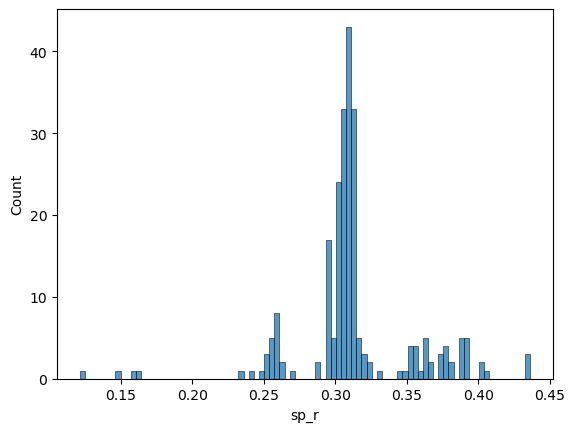

In [77]:
sns.histplot(metrics['sp_r'])

In [78]:
with open('./../data/proclam/esm2_t6_8M_UR50D/models.pickle', 'wb') as handle:
    pickle.dump(models, handle)

## Ensemble model

In [72]:
predictions = []
for t_d, m in zip(test_data, models):
    predictions.append(pd.Series(index=t_d.index, data=m.predict(t_d)))
    

In [ ]:
with open('./../data/proclam/esm2_t6_8M_UR50D/train_data.pickle', 'wb') as handle:
    pickle.dump(train_data, handle)

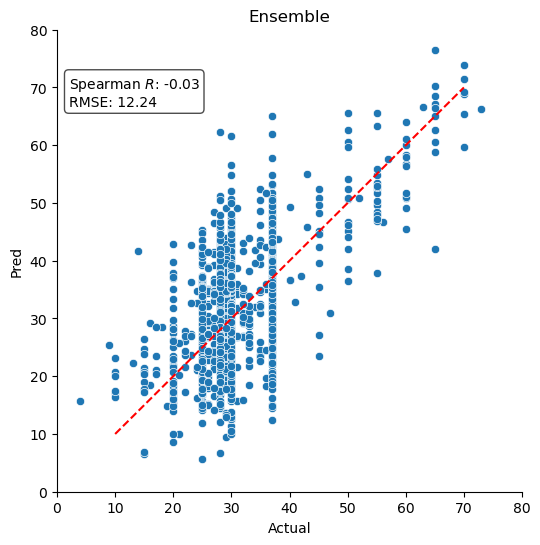

In [82]:
fig, ax = plt.subplots(figsize=(6,6))

sns.scatterplot(y=pd.concat(predictions, axis=1).mean(1),
        x=y_test)

plt.plot([10, 70], [10, 70], color='r', linestyle='--')


# ax.set_aspect('equal')
ax.set_ylim(0, 80)
ax.set_xlim(0, 80)

sns.despine()
ax.set_ylabel('Pred')
ax.set_xlabel('Actual')
ax.set_title('Ensemble')

rmse = np.sqrt(mean_squared_error(pd.concat(predictions, axis=1).mean(1), y_test))
sp_r = spearmanr(pd.concat(predictions, axis=1).mean(1), y_test)[0]

ax.text(0.025, 0.9,
            f"Spearman $R$: {sp_r:.2f}\nRMSE: {rmse:.2f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# plt.savefig('./../data/figures/20250626_esm2_ensemble_accuracy.png', dpi=400, bbox_inches='tight')

plt.show()




In [84]:
pd.concat(predictions, axis=1).mean(1)

NZ_CP016353.1_567|RS_GCF_002240355.1|adk|temp=28.0|bitscore=173.6         33.176151
NZ_MPZN01000005.1_24|RS_GCF_002936985.1|adk|temp=23.0|bitscore=156.6      42.721790
NZ_CP029642.1_3780|RS_GCF_003268655.1|adk|temp=25.0|bitscore=171.1        24.692705
NZ_SDHY01000003.1_223|RS_GCF_004118285.1|adk|temp=26.0|bitscore=180.4     32.221355
NZ_CP007490.1_1186|RS_GCF_000699505.1|adk|temp=22.0|bitscore=174.6        26.052767
                                                                            ...    
NZ_CP042806.1_3264|RS_GCF_008000815.1|adk|temp=28.0|bitscore=149.3        32.392635
NZ_JNIF01000003.1_1698|RS_GCF_000702445.1|adk|temp=28.0|bitscore=147.9    20.050980
NZ_KI421509.1_4100|RS_GCF_000473225.1|adk|temp=28.0|bitscore=185.4        31.453604
NZ_AP019755.1_58|RS_GCF_006742785.1|adk|temp=30.0|bitscore=194.1          24.192747
NZ_AZDJ01000030.1_339|RS_GCF_001434705.1|adk|temp=30.0|bitscore=181.2     52.140942
Length: 1706, dtype: float32

## Tuned MSA transformer

In [93]:
import torch
import random
from collections import defaultdict
from typing import List, Tuple, Optional, Dict, NamedTuple, Union, Callable
import itertools
import os
import string
from pathlib import Path

import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from scipy.spatial.distance import squareform, pdist, cdist

import esm


In [91]:
# Select sequences from the MSA to maximize the hamming distance
# Alternatively, can use hhfilter 
def greedy_select(msa: List[Tuple[str, str]], num_seqs: int, mode: str = "max") -> List[Tuple[str, str]]:
    assert mode in ("max", "min")
    if len(msa) <= num_seqs:
        return msa
    
    array = np.array([list(seq) for _, seq in msa], dtype=np.bytes_).view(np.uint8)

    optfunc = np.argmax if mode == "max" else np.argmin
    all_indices = np.arange(len(msa))
    indices = [0]
    pairwise_distances = np.zeros((0, len(msa)))
    for _ in range(num_seqs - 1):
        dist = cdist(array[indices[-1:]], array, "hamming")
        pairwise_distances = np.concatenate([pairwise_distances, dist])
        shifted_distance = np.delete(pairwise_distances, indices, axis=1).mean(0)
        shifted_index = optfunc(shifted_distance)
        index = np.delete(all_indices, indices)[shifted_index]
        indices.append(index)
    indices = sorted(indices)
    return [msa[idx] for idx in indices]


In [96]:
# Load pretrained MSA Transformer
model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
model.eval()

# Get batch converter
batch_converter = alphabet.get_batch_converter()

           # Shape: (1, L, L)


In [99]:
with open('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/20240122_all_adks_filtered.afa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle=handle,format='fasta')]

In [100]:
records[0]

SeqRecord(seq=Seq('------------------------------------------------------...---'), id='CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3', name='CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3', description='CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3', dbxrefs=[])

In [ ]:
# Example MSA (list of tuples: (description, sequence))
msa = [
    ("query", "MQDRVKRPMNAFIVWSRDQRRKMALEN"),
    ("homolog1", "MKDRVKRPMNAFIVWSRDQRRKMALEN"),
    ("homolog2", "MQRAVKRPLNAFIVWSRDQRRKVALEN"),
    # Add up to 128 sequences here
]

# Prepare batch (single MSA → one item list)
labels, strs, tokens = batch_converter([msa])

# Run the model
with torch.no_grad():
    output = model(tokens, repr_layers=[12], return_contacts=True)

# Get attention representations and contact map
representations = output["representations"][12]     # Shape: (1, Nseqs, L, 768)
contact_probs = output["contacts"]       

torch.Size([1, 3, 28, 768])

In [ ]:

class OGTRegressor(nn.Module):
    def __init__(self, input_dim=768, pooling='mean'):
        super().__init__()
        self.pooling = pooling
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):  # x: (L, D)
        if self.pooling == 'mean':
            x = x.mean(dim=0)  # (D,)
        elif self.pooling == 'cls':
            x = x[0]  # [CLS] token if used
        return self.fc(x)


In [ ]:


class MSADataset(Dataset):
    def __init__(self, seqs_with_ogt):
        self.ids = list(seqs_with_ogt.keys())
        self.data = seqs_with_ogt

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        query_id = self.ids[idx]
        msa = sample_msa(self.data, query_id)
        ogt = self.data[query_id][1]
        return msa, ogt

def train_ogt_predictor(dataset, epochs=10, lr=1e-4):
    loader = DataLoader(dataset, batch_size=1, shuffle=True)
    regressor = OGTRegressor().to(device)
    optimizer = optim.Adam(regressor.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        total_loss = 0
        for msa, ogt in loader:
            msa = msa[0]  # unpack
            ogt = ogt.to(device).float()

            emb = embed_msa(msa)  # shape: (L, D)
            pred = regressor(emb).squeeze()
            loss = loss_fn(pred, ogt)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}: Loss = {total_loss / len(loader):.4f}")

    return regressor


In [ ]:
# Your data: dict of {protein_id: (sequence_string, ogt_float)}
seqs_with_ogt = {
    'org1': ('MKTAYL...', 37.0),
    'org2': ('MKDAYL...', 55.0),
    ...
}

dataset = MSADataset(seqs_with_ogt)
model = train_ogt_predictor(dataset)


In [111]:
y.value_counts().pipe(lambda x: x[x.index < 15]).sum()

41

# End of current code

In [ ]:
pd.concat(predictions, axis=1).mean(1)

In [42]:
for index, row in aln_df.head().iterrows():
    seq_str = ''.join(row[~row.eq('-')].astype(str))
    seq_embed = [p for p in dataset.proteins if p.label == index][0].sequence
    print(seq_str)
    print(seq_embed)

MNIILLGPPGAGKGTQASKLVADRGMVQLSTGDMLRAAVKAGTPIGLKAKAVMEAGELVSDEIVSGLIGEKLDSMAASEGAIFDGYPRTEAQAHSLDEILASRGRVLDHVIELEVDEDALVERITGRYTCANCGEGYHDRFKQPKVAGVCDVCGSAEFKRRPDDNEETVRTRMAEYRAKTAPILPVYEARGLVRRVDGMADMADVSAAIAAILDN
MNIILLGPPGAGKGTQASKLVADRGMVQLSTGDMLRAAVKAGTPIGLKAKAVMEAGELVSDEIVSGLIGEKLDSMAASEGAIFDGYPRTEAQAHSLDEILASRGRVLDHVIELEVDEDALVERITGRYTCANCGEGYHDRFKQPKVAGVCDVCGSAEFKRRPDDNEETVRTRMAEYRAKTAPILPVYEARGLVRRVDGMADMADVSAAIAAILDN
MMGIVMLGAPGAGKGTQAKRIADYYRIPHISTGDIFRANIKAGTPLGLEAKRYMDAGGLVPDEVTIGMLKDRIHEADCGEGYVLDGFPRTIPQAEALTEALAAEGTKIDEAVDIEVPDEAIIDRMEGRRSCPNCGESYHVRYRAPKTENICDVCGHALVQRADDKPETVAARLRVYHEQTKPLIDYYRGQGVLREVDGTQEMGEVFEAIKALL
MLYIAMGTLAKEKAVKIVMLGAPGAGKGTQAKRIADYYRIPHISTGDIFRANIKAGTPLGLEAKRYMDAGGLVPDEVTIGMLKDRIHEADCGEGYVLDGFPRTIPQAEALTEALAAEGTKIDEAVDIEVPDEAIIDRMEGRRSCPNCGESYHVRYRAPKTENICDVCGHALVQRADDKPETVAARLRVYHEQTKPLIDYYRGQGVLREVDGTQEMGEVFEAIKALL
MRLILLGAPGAGKGTQAEILCKEFSIPTISTGNILRVAIKNGTPTGLKAKSFMDAGKLVPDDVIIGVITDRLAESDCANGYILDGVPRTIAQAEALEKAGINFDDVVSIEISDQEIKERMAGRRVCE

'MNIILLGPPGAGKGTQASKLVADRGMVQLSTGDMLRAAVKAGTPIGLKAKAVMEAGELVSDEIVSGLIGEKLDSMAASEGAIFDGYPRTEAQAHSLDEILASRGRVLDHVIELEVDEDALVERITGRYTCANCGEGYHDRFKQPKVAGVCDVCGSAEFKRRPDDNEETVRTRMAEYRAKTAPILPVYEARGLVRRVDGMADMADVSAAIAAILDN'

In [30]:
dataset.proteins[0].label

'NZ_UHIA01000004.1_990|RS_GCF_900460215.1|adk|temp=37.0|bitscore=183.2'

In [1190]:
trim_aln_df = aln_df.iloc[:, kept_cols]

In [1191]:
def get_ungapped_loc(row, aligned_site):
    ## get unaligned version of row
    ref1 = row[~row.eq('-')]
    ## make index of aligned -> unaligned (minus gaps)
    ref2 = pd.Series(index=ref1.index, data=list(range(len(ref1))))
    ## get where the requested aligned site fell in original sequence
    if not aligned_site in ref2.index:
        return -1, '-'
    
    og_site = ref2.loc[aligned_site]
    ## return location of OG site and residue
    # print(ref1.index.values)
    return og_site, ref1.iloc[og_site]

def get_og_locs(aln_df, trim_df, trim_df_site):
    ## get the ith site from the trim_df: series name tells
    ## what site in original alignment it is
    site = trim_df.iloc[:, trim_df_site]
    print(f'Site retrieved: {site.name}')
    return aln_df.apply(lambda row: get_ungapped_loc(row, site.name), axis=1).rename(f'{trim_df_site}->{site.name}->X')

### Working with embeddings

#### Load trees

In [1192]:
# rewrite tree to remove internal node names and supports
ancseq_tree = Tree('./../data/csubst_analysis/ancseq/ancseq_out/30_result/ancestral_state_result.treefile', format=1)

csubst_tree = Tree('./../data/csubst_analysis/csubst_hot/csubst_tree.nwk', format=1)

tree_name_map = pd.Series()
tree2name= pd.Series()
for node in csubst_tree.traverse():
    if not node.is_root():
        tree_name_map.loc[node.name.split('|')[0]] = node.name.split('|')[1]
        tree2name.loc[node.name.split('|')[1]] = node.name.split('|')[0]

The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.


#### Load embeddings for sites 

In [1193]:
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from Bio.Align import substitution_matrices

def align_fast(seq1, seq2):
    # Load a BLOSUM matrix (BLOSUM62 is commonly used)
    blosum62 = substitution_matrices.load("BLOSUM62")
    # Perform global alignment with BLOSUM62
    # gap_open and gap_extend parameters can be adjusted as needed
    alignments = pairwise2.align.globalds(seq1, seq2, blosum62, -10, -0.5)
    
    # Get the best alignment
    aligned_seq1, aligned_seq2, score, start, end = alignments[0]
    return aligned_seq1, aligned_seq2, score, start, end

In [2158]:

# pd.DataFrame(index=final_genome_list, 
embeddings = []
POSITION = 200
position_map = get_og_locs(aln_df, trim_aln_df, POSITION)
tsne_index = []
check_lengths = []
for i, g in enumerate(position_map.index):
    # print(g)
    # if i  % 5 == 0:
    #     display(i / len(position_map))
    #     clear_output(wait=True)
    potential_proteins = [p for p in dataset.proteins if g == p.label.split(' ')[0]]
    check_lengths.append(len(potential_proteins))
    _protein = potential_proteins[0]

    e = _protein.get_embedding()
    loc = position_map.loc[g][0]
    res = position_map.loc[g][1]

    # try:
    if 0 < loc <= e.shape[0]:
        # print(loc, e.shape)
        
        embeddings.append(e[loc+1, :])
        residues.append(_protein.sequence[loc])

        # check for niche error where the alignment excludes a fragment
        row = aln_df.loc[g, :]
        row_str = ''.join(list(row[~row.eq('-')].values))
        
        try:
            assert len(_protein.sequence) == len(row_str)
            
        except AssertionError:
            # niche error means some things might have part of the sequence excluded in the alignment
            # if it has no homolog in leaf sequences
            # see mafft alignment 
            aln_row, aln_protein, score, start, end = align_fast(row_str, _protein.sequence)

            # this test must pass
            assert aln_row[loc] == aln_protein[loc]
            
        tsne_index.append(g)

    else:
        print('Site is a gap', loc, e.shape)
    # print(len(embeddings), len(tsne_index))

Site retrieved: 302


<AxesSubplot:xlabel='200->302->X', ylabel='mean_temp'>

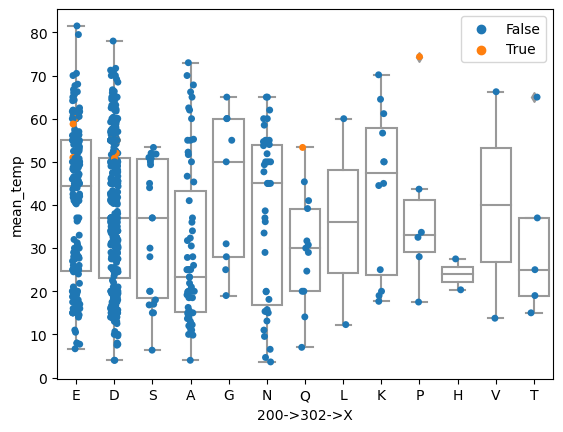

In [2159]:
plotdf = pd.merge(position_map.apply(lambda x: x[1]), genome2temp['mean_temp'],
         left_index=True, right_index=True)
sns.boxplot(data=plotdf,
            x=plotdf.columns[0], y='mean_temp', color='white')
sns.stripplot(data=plotdf,
            x=plotdf.columns[0], y='mean_temp', hue=plotdf.index.isin(branch_convergent_sites.branch.unique()))

In [2160]:
tsne_plotdf = pd.DataFrame(embeddings, index=tsne_index)

In [2161]:
tsne_plotdf

,0,1,2,3,4,5,6,7,8,9,...,310,311,312,313,314,315,316,317,318,319
GB_GCA_003148465.1,0.216976,-0.564542,0.126547,0.234848,0.269966,-0.101916,0.298154,-0.026242,-0.026810,0.710878,...,0.224291,-0.372540,-0.653814,-0.366878,0.284309,-0.040956,-0.320651,-0.628478,0.223386,-0.760387
GB_GCA_010730955.1,0.316214,-0.700043,-0.123006,-0.202339,0.176766,-0.432101,0.013346,0.036958,-0.014745,0.766639,...,-0.009978,-0.134275,-0.345420,-0.055025,0.107517,-0.191699,-0.269215,-0.379278,-0.235561,-0.672350
RS_GCF_000006985.1,0.511440,-0.604262,0.224470,0.036652,0.105790,-0.207070,0.217412,-0.055273,0.100235,0.602595,...,-0.572856,-0.454348,-0.536838,-0.328210,0.194738,-0.567166,-0.130677,-0.901910,-0.194187,-0.782225
RS_GCF_000007905.1,0.390824,-0.557965,0.262795,-0.055173,0.249913,-0.268244,-0.045735,0.190856,-0.047411,0.451189,...,0.133027,0.047888,-0.319908,0.279736,0.220777,0.156530,-0.093580,-0.459078,-0.296729,-0.535980
RS_GCF_000009905.1,0.436974,-0.334191,0.359325,-0.009425,0.200256,-0.155290,0.253234,-0.008549,-0.345856,0.819925,...,-0.313608,-0.608686,-0.520467,-0.233166,0.187897,-0.688826,-0.024427,-0.809755,-0.014582,-0.812528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Node750,0.330787,-0.712536,0.118618,-0.286873,0.320103,-0.339393,0.006096,0.218933,-0.402036,0.534411,...,-0.019112,-0.233838,-0.583014,0.227735,0.206706,-0.205380,-0.149292,-0.299628,-0.203801,-0.501523
Node724,0.319554,-0.722683,0.109317,-0.274443,0.320502,-0.333846,-0.006734,0.205611,-0.405827,0.534664,...,-0.026583,-0.225977,-0.589875,0.222595,0.204353,-0.203789,-0.153905,-0.294171,-0.218355,-0.498143
Node717,0.200952,-0.618225,0.119199,-0.249412,0.200557,-0.369876,0.081401,0.105415,-0.290981,0.587004,...,-0.036022,-0.275540,-0.467016,0.061606,0.190527,-0.207614,-0.087597,-0.404382,-0.087329,-0.698172
Node636,0.239068,-0.615573,0.143041,-0.280645,0.135147,-0.347195,0.186025,0.028328,-0.077266,0.588252,...,-0.149965,-0.237284,-0.479176,-0.080246,0.192653,-0.186058,-0.182234,-0.406399,-0.184304,-0.873432


#### Modify tree to match embeddings

In [2105]:
embedding_tree = ancseq_tree.copy()

embedding_tree

def layout(node):
    ns = NodeStyle()
    if not node.name in tsne_plotdf.index:
        print(node.name)
        ns['size'] = 5
    else:
        ns['size'] = 0
        
    node.img_style = ns

ts = TreeStyle()
ts.layout_fn = lambda n: layout(n)
# ts.scale=500
ts.mode = 'c'
ts.show_leaf_name = False
ts.draw_guiding_lines = False

embedding_tree.render('%%inline', tree_style=ts)

'''
#### Notes
Here's the solution: re-align the original sequences + ancestral sequences with mafft without the keeplength option, trim with backtranslation in Trimal, remove the ancestral sequences, and then use the trimmed alignment for this and trimmed - minus ancestral for CSUBST. There's not actually this many gaps: the alignment is just screwed up because I used the --keeplength option
'''

for node in embedding_tree.traverse():
    if not node.name in tsne_plotdf.index and not node.is_root():
        print(node.name)
        for subnode in node.traverse():
            if subnode.name in tsne_plotdf.index:
                print(f'Uh oh, a subnode of {node.name} (called {subnode.name} is in the embedding')
        

## This is where phylogenetic PCA would go

In [2150]:
tsne_plotdf.to_csv(f'./../data/csubst_analysis/pca_dfs/{POSITION}_embedding_all.tsv', sep='\t')

In [2151]:
tsne_plotdf[~tsne_plotdf.index.str.contains('Node')].to_csv(f'./../data/csubst_analysis/pca_dfs/{POSITION}_embedding_tips.tsv', sep='\t')

In [1212]:
# read in PCA data
ppca_data = pd.read_csv('./../data/csubst_analysis/pca_dfs/186_ppca_scores.tsv', sep='\t', index_col=0)

# read PPCA predicted with ancestral sequence reconstruction
internal_ppca_data = pd.read_csv('./../data/csubst_analysis/pca_dfs/186_ppca_internal_node_scores.tsv', sep='\t', index_col=0)

# make combined data
tsne_ppca = pd.concat([ppca_data, internal_ppca_data])

In [2162]:
# Example embeddings: 100 points, each with 768 features
np.random.seed(42)

# Reduce to 2D
tsne = TSNE(n_components=2, perplexity=60, random_state=143)
# embedding_2d = pd.DataFrame(tsne.fit_transform(tsne_ppca.values),
#                             index=tsne_ppca.index, columns=['dim1', 'dim2'])

embedding_2d = pd.DataFrame(tsne.fit_transform(tsne_plotdf.values),
                            index=tsne_plotdf.index, columns=['dim1', 'dim2'])


The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.


### Raw PPCA plot

In [2163]:
result.head()

,branch_id_1,branch_id_2,branch_id_3,dist_bl,dist_node_num,branch_num_fg,branch_num_fg_stem,branch_num_mg,is_fg,is_mf,...,ECNspe2spe,ECSany2any,ECSany2dif,ECSany2spe,ECSdif2any,ECSdif2dif,ECSdif2spe,ECSspe2any,ECSspe2dif,ECSspe2spe
17,77,212,657,4.7712,24.0,3,3,0,Y,N,...,0.0419,2.0807,1.9585,0.1222,2.0342,1.9387,0.0954,0.0465,0.0197,0.0268
19,77,657,783,5.2001,28.0,3,3,0,Y,N,...,0.0512,3.2249,3.0379,0.1871,3.1474,3.0044,0.1430,0.0775,0.0334,0.0441
20,77,657,919,5.8157,24.0,3,3,0,Y,N,...,0.0290,1.9726,1.8615,0.1111,1.9360,1.8427,0.0933,0.0365,0.0188,0.0177
22,77,657,1074,4.7712,25.0,3,3,0,Y,N,...,0.0633,2.7740,2.6202,0.1538,2.7245,2.6010,0.1235,0.0495,0.0192,0.0303
40,105,173,417,6.4804,34.0,3,3,0,Y,N,...,0.0287,4.6195,4.3099,0.3096,4.3707,4.1468,0.2239,0.2488,0.1631,0.0857


In [2164]:
'''
collate per-site contacts and SASA measured from structures with alphafold
'''
per_res_data = pd.read_csv('./../../data/metric_tables/20240528_full_metrics_lid.tsv.gz', 
                           sep=',', compression='gzip', index_col=0)

site_position_df  = position_map.apply(lambda x: pd.Series(data=list(x), index=['location', 'residue']))
site_position_df['location'] =  site_position_df['location'] + 1
site_position_df #.location.value_counts()

position_map

for i, protein in enumerate(position_map[~position_map.index.str.contains('Node')].index):
    
    display(i)
    clear_output(wait=True)
    
    subset = per_res_data[per_res_data.uid.eq(protein)]
    
    merged_subset = pd.merge(site_position_df.reset_index(), 
                         subset,
                         left_on=['index', 'location'], 
                         right_on=['uid', 'Position'], how='inner')
    
    if len(merged_subset) != 1:
        print('uh oh', len(merged_subset))
        break

merged_site_map = pd.merge(site_position_df.reset_index(), 
         per_res_data,
         left_on=['index', 'location'], 
         right_on=['uid', 'Position'], how='inner')

merged_site_map['temp'] =  genome2temp.reindex(merged_site_map.uid)['mean_temp'].values

752

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


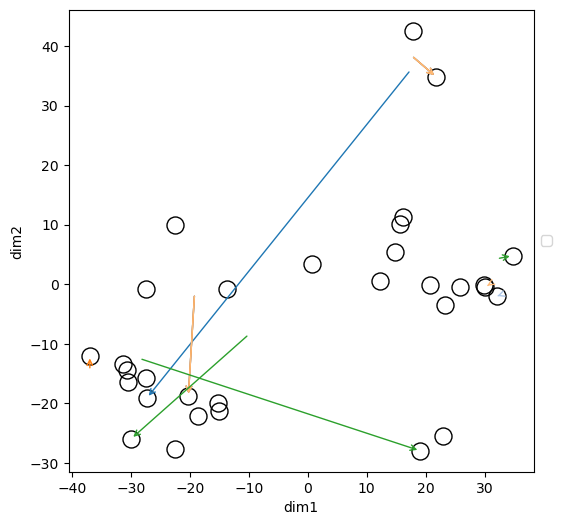

In [2174]:
fig, ax = plt.subplots(figsize=(6,6))
clades_of_interest = np.unique(result[[c for c in result.columns if 'branch_id' in c]].values.flatten())

g = sns.scatterplot(x=embedding_2d.loc[tree2name.loc[[str(s) for s in clades_of_interest]]]['dim1'],
               y=embedding_2d.loc[tree2name.loc[[str(s) for s in clades_of_interest]]]['dim2'], 
                color='white', linewidth=1, edgecolor='black', s=150, zorder=1)

# Make facecolor fully transparent for each artist
for artist in g.collections:
    artist.set_facecolor((1, 1, 1, 0))  # RGBA: white with 0 alpha

# g1 = sns.scatterplot(x=embedding_2d['dim1'].sort_index(), 
#             y=embedding_2d['dim2'].sort_index(), 
#             alpha=0.7, 
#             hue=merged_site_map.set_index('index').reindex(embedding_2d.index)['SASA'], #['Contacts at 4.5 Å'],
#                 # genome2temp.reindex(embedding_2d.index)['mean_temp'].fillna(-1),
#             palette='viridis',
#             style=position_map.index.to_series().apply(lambda x: "Node" in x))

lgd = g1.legend(loc='center left', bbox_to_anchor=(1,0.5))

# for node in list(ancseq_tree.traverse(strategy='levelorder')):
    
#     if not node.is_leaf() and not node.is_root():
#         children = node.get_children()
        
#         xy = embedding_2d.loc[node.name, :].values

#         for c in children:

#             xy_c = embedding_2d.loc[c.name, :].values

#             if int(tree_name_map.loc[c.name]) in clades_of_interest:

#                 color = 'red'
#                 zorder=1
#                 ax.annotate(text=tree_name_map.loc[c.name],
#                             xy=xy_c, ha='center', va='center')

#                 ax.annotate(text='', 
#                             xytext=xy, # from
#                             xy=xy_c, # to
#                             arrowprops=dict(
#                                 arrowstyle="->", 
#                                 color=color,
#                                 linewidth=1
#                             ),
#                             zorder=zorder, ha='center', va='center')
                
                
lgd = ax.legend(loc='center left', bbox_to_anchor=(1,0.5))
arrow_color = 'k'
for (index, row), arrow_color in zip(result.head(5).iterrows(), sns.color_palette('tab20', n_colors=len(result))):
    
    for node in list(ancseq_tree.traverse(strategy='levelorder')):

        if not node.is_leaf() and not node.is_root():
            children = node.get_children()

            xy = embedding_2d.loc[node.name, :].values

            for c in children:

                xy_c = embedding_2d.loc[c.name, :].values

                if int(tree_name_map.loc[c.name]) in row.iloc[:3].values:

                    color = 'red'
                    zorder=1
                    ax.annotate(text='', #tree_name_map.loc[c.name],
                                xy=xy_c, ha='center', va='center')

                    ax.annotate(text='', 
                                xytext=xy, # from
                                xy=xy_c, # to
                                arrowprops=dict(
                                    arrowstyle="->", 
                                    color=arrow_color,
                                    linewidth=1
                                ),
                                zorder=zorder, ha='center', va='center')


In [2153]:
merged_site_map

,index,location,residue_x,Position,Contacts at 4.5 Å,SASA,uid,lid,residue_y,temp
0,GB_GCA_003148465.1,210,R,210,13,118.242887,GB_GCA_003148465.1,False,R,50.000000
1,GB_GCA_010730955.1,180,G,180,5,69.747123,GB_GCA_010730955.1,False,G,31.333333
2,RS_GCF_000006985.1,217,N,217,7,110.461602,RS_GCF_000006985.1,False,N,42.525029
3,RS_GCF_000007905.1,187,K,187,10,111.150393,RS_GCF_000007905.1,False,K,41.500000
4,RS_GCF_000009905.1,213,R,213,7,209.947299,RS_GCF_000009905.1,False,R,60.000000
...,...,...,...,...,...,...,...,...,...,...
738,RS_GCF_900637165.1,188,G,188,11,39.926752,RS_GCF_900637165.1,False,G,40.500000
739,RS_GCF_901905185.1,192,Q,192,6,177.735834,RS_GCF_901905185.1,False,Q,15.000000
740,RS_GCF_904846055.1,217,K,217,8,136.715896,RS_GCF_904846055.1,False,K,31.666667
741,RS_GCF_904846075.1,217,K,217,7,147.372965,RS_GCF_904846075.1,False,K,15.000000


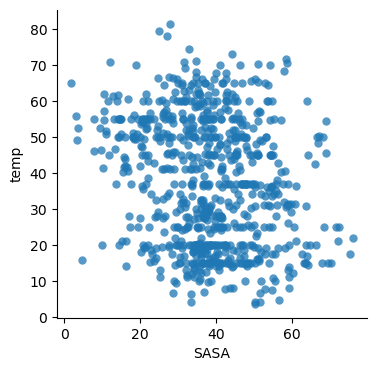

In [2034]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(data=merged_site_map,
                x='SASA',
                y='temp', linewidth=0, alpha=0.75)

sns.despine()



In [1688]:
merged_site_map

,index,location,residue_x,Position,Contacts at 4.5 Å,SASA,uid,lid,residue_y,temp
0,GB_GCA_003148465.1,185,K,185,6,196.138872,GB_GCA_003148465.1,False,K,50.000000
1,GB_GCA_010730955.1,157,D,157,5,147.909404,GB_GCA_010730955.1,False,D,31.333333
2,RS_GCF_000006985.1,184,N,184,9,88.608751,RS_GCF_000006985.1,False,N,42.525029
3,RS_GCF_000007905.1,162,K,162,7,177.891079,RS_GCF_000007905.1,False,K,41.500000
4,RS_GCF_000009905.1,188,E,188,7,136.297796,RS_GCF_000009905.1,False,E,60.000000
...,...,...,...,...,...,...,...,...,...,...
748,RS_GCF_900637165.1,163,S,163,7,104.289986,RS_GCF_900637165.1,False,S,40.500000
749,RS_GCF_901905185.1,167,A,167,7,98.348629,RS_GCF_901905185.1,False,A,15.000000
750,RS_GCF_904846055.1,185,D,185,9,88.411530,RS_GCF_904846055.1,False,D,31.666667
751,RS_GCF_904846075.1,185,D,185,9,84.431122,RS_GCF_904846075.1,False,D,15.000000


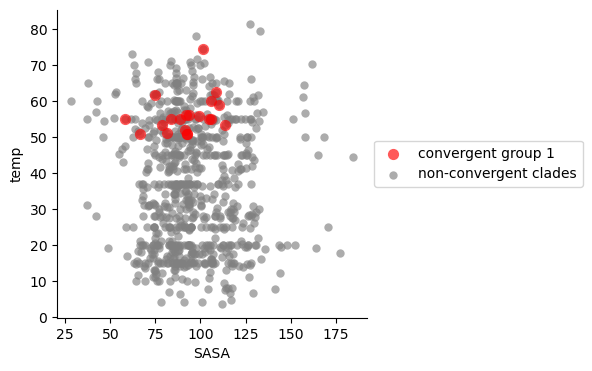

In [2175]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(data=merged_site_map[merged_site_map['index'].isin(tree2name.loc[[str(s) for s in clades_of_interest]])],
                x='SASA',
                y='temp', 
                color='red', 
                label='convergent group 1',
                linewidth=0, alpha=0.65, zorder=1, s=65)

sns.scatterplot(data=merged_site_map,
                x='SASA',
                y='temp', 
                color='gray',
                label='non-convergent clades',
                linewidth=0, alpha=0.65, zorder=0)


lgd = ax.legend(loc='center left', bbox_to_anchor=(1,0.5))
sns.despine()


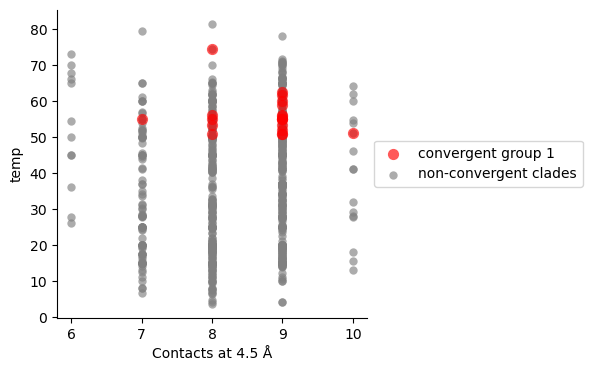

In [2176]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(data=merged_site_map[merged_site_map['index'].isin(tree2name.loc[[str(s) for s in clades_of_interest]])],
                x='Contacts at 4.5 Å',
                y='temp', 
                color='red', 
                label='convergent group 1',
                linewidth=0, alpha=0.65, zorder=1, s=65)

sns.scatterplot(data=merged_site_map,
                x='Contacts at 4.5 Å',
                y='temp', 
                color='gray',
                label='non-convergent clades',
                linewidth=0, alpha=0.65, zorder=0)


lgd = ax.legend(loc='center left', bbox_to_anchor=(1,0.5))
sns.despine()


<AxesSubplot:xlabel='Contacts at 4.5 Å', ylabel='SASA'>

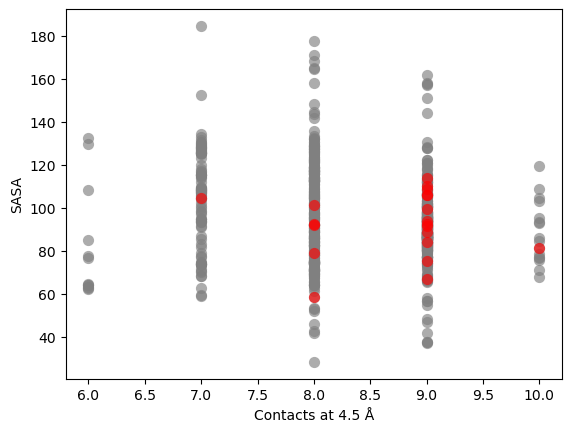

In [2177]:
sns.scatterplot(data=merged_site_map,
                x='Contacts at 4.5 Å',
                y='SASA', 
                # hue=merged_site_map['index'].isin([tree2name.loc[str(c)] for c in clades_of_interest]),
                color='gray', 
                # label='convergent group 5',
                linewidth=0, alpha=0.65, zorder=1, s=65)


sns.scatterplot(data=merged_site_map[merged_site_map['index'].isin([tree2name.loc[str(c)] for c in clades_of_interest])],
                x='Contacts at 4.5 Å',
                y='SASA', 
                # hue=merged_site_map['index'].isin([tree2name.loc[str(c)] for c in clades_of_interest]),
                color='red', 
                # label='convergent group 5',
                linewidth=0, alpha=0.65, zorder=1, s=65)

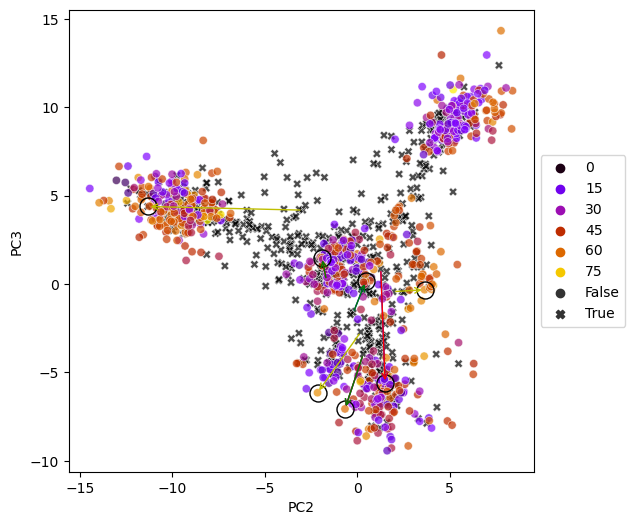

In [1751]:
fig, ax = plt.subplots(figsize=(6,6))

x, y  = 'PC2', 'PC3'

clades_of_interest = np.unique(result[[c for c in result.columns if 'branch_id' in c]].values.flatten())

g = sns.scatterplot(x=tsne_ppca.loc[tree2name.loc[[str(s) for s in clades_of_interest]]][x],
               y=tsne_ppca.loc[tree2name.loc[[str(s) for s in clades_of_interest]]][y], 
                color='white', linewidth=1, edgecolor='black', s=150, zorder=1)

# Make facecolor fully transparent for each artist
for artist in g.collections:
    artist.set_facecolor((1, 1, 1, 0))  # RGBA: white with 0 alpha
    
g1 = sns.scatterplot(x=tsne_ppca[x], 
            y=tsne_ppca[y], 
            alpha=0.7, 
            hue=genome2temp.reindex(tsne_ppca.index)['mean_temp'].fillna(-1),
            palette='gnuplot',
            style=position_map.index.to_series().apply(lambda x: "Node" in x),  zorder=0)

lgd = ax.legend(loc='center left', bbox_to_anchor=(1,0.5))
for (index, row), arrow_color in zip(result.iterrows(), ['b', 'r', 'g', 'y']):
    
    for node in list(ancseq_tree.traverse(strategy='levelorder')):

        if not node.is_leaf() and not node.is_root():
            children = node.get_children()

            xy = tsne_ppca.loc[node.name, [x,y]].values

            for c in children:

                xy_c = tsne_ppca.loc[c.name, [x,y]].values

                if int(tree_name_map.loc[c.name]) in row.iloc[:3].values:

                    color = 'red'
                    zorder=1
                    ax.annotate(text='', #tree_name_map.loc[c.name],
                                xy=xy_c, ha='center', va='center')

                    ax.annotate(text='', 
                                xytext=xy, # from
                                xy=xy_c, # to
                                arrowprops=dict(
                                    arrowstyle="->", 
                                    color=arrow_color,
                                    linewidth=1
                                ),
                                zorder=zorder, ha='center', va='center')


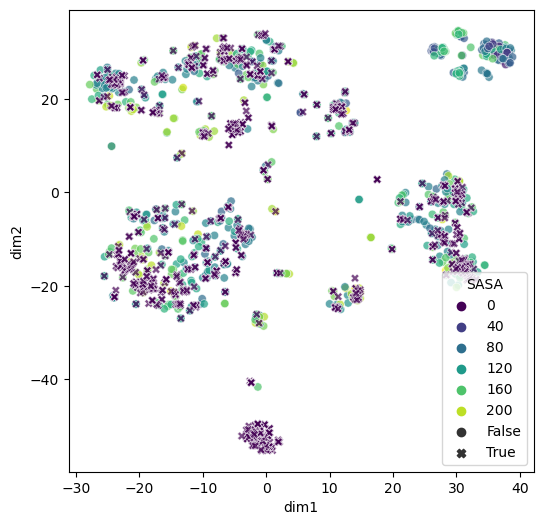

In [1709]:
fig, ax = plt.subplots(figsize=(6,6))

sns.scatterplot(x=embedding_2d['dim1'], 
            y=embedding_2d['dim2'], 
            alpha=0.7, 
            hue=merged_site_map.set_index('index').reindex(embedding_2d.index)['SASA'].fillna(-1),
            # hue=merged_site_map.set_index('index').reindex(embedding_2d.index)['Contacts at 4.5 Å'].fillna(-1),
            palette='viridis',
            style=position_map.index.to_series().apply(lambda x: "Node" in x))

# sns.scatterplot(x=embedding_2d.loc[tree2name.loc[[str(s) for s in clades_of_interest]]]['dim1'],
#                y=embedding_2d.loc[tree2name.loc[[str(s) for s in clades_of_interest]]]['dim2'], 
#                 color='r', linewidth=1, size=150, zorder=1)

plt.show()

In [1695]:
from scipy.spatial.distance import pdist, squareform


In [1699]:
# Compute pairwise distances (e.g., Euclidean)
dist_array = pdist(tsne_plotdf.values, metric='euclidean')

# Convert to square distance matrix
dist_matrix = pd.DataFrame(
    squareform(dist_array),
    index=tsne_plotdf.index,
    columns=tsne_plotdf.index
)

<AxesSubplot:ylabel='Count'>

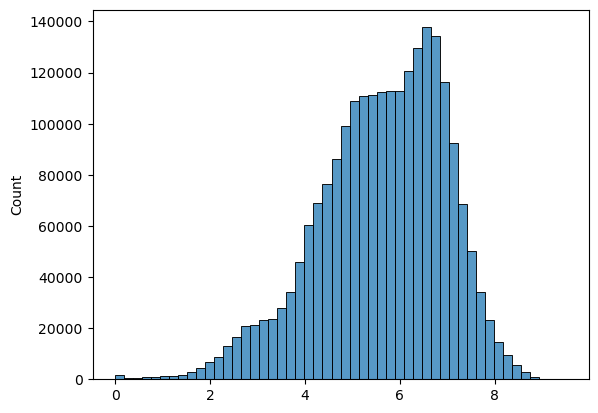

In [1700]:
sns.histplot(dist_matrix.values.flatten(), bins=50)


In [1701]:
def get_direction_of_shared_change(pca_scores: pd.DataFrame, node_pairs: list, normalize=True):
    change_vectors = []
    
    for ancestor, descendant in node_pairs:
        if ancestor not in pca_scores.index or descendant not in pca_scores.index:
            continue  # skip missing nodes
        v = pca_scores.loc[descendant].values - pca_scores.loc[ancestor].values
        if normalize:
            v = v / np.linalg.norm(v)
        change_vectors.append(v)
    
    V = np.vstack(change_vectors)  # shape = (n_pairs, n_PCs)
    
    # SVD: V = U Σ R^T
    _, _, R = np.linalg.svd(V, full_matrices=False)
    
    leading_direction = R[0]  # first right-singular vector
    return leading_direction, V

In [1702]:
pairs = []
for node in ['25', '37', '206']:
    node1 = ancseq_tree.search_nodes(name=tree2name.loc[node])[0]
    pairs.append((node1.up.name, node1.name))

In [1703]:
# Get the shared direction (linear combination of PCs)
direction, vectors_used = get_direction_of_shared_change(tsne_ppca, pairs)

# Project all nodes onto this direction
meta_pc = tsne_ppca.values @ direction

In [1704]:
direction.shape

(320,)

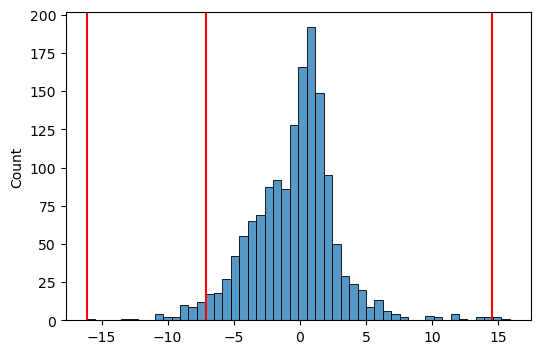

In [1705]:
fig, ax = plt.subplots(figsize=(6,4))
meta_pc_series = pd.Series(index=tsne_ppca.index, data=meta_pc)
sns.histplot(meta_pc_series)
for item in meta_pc_series.loc[tree2name.loc[[str(s) for s in ['25', '37', '206']]].values]:
    ax.axvline(item, color='r')

# for line in 

In [1246]:
csubst_site = pd.read_csv('./../data/csubst_analysis/csubst_hot/csubst_site.branch_id25,37,206/csubst_site.tsv', sep='\t')

In [1338]:
internal_ancestral_states = pd.read_csv('./../data/ancestral_states.tsv', sep='\t')['trait']

<AxesSubplot:xlabel='OCNany2spe'>

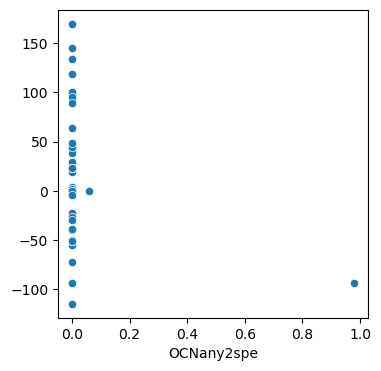

In [1276]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.scatterplot(x=csubst_site['OCNany2spe'],
                y=csubst_site['aa_25_hydrophobicity'] - csubst_site['aa_25_anc_hydrophobicity'] )

# ax.set_ylim(-100, 100)

<AxesSubplot:xlabel='OCNany2spe'>

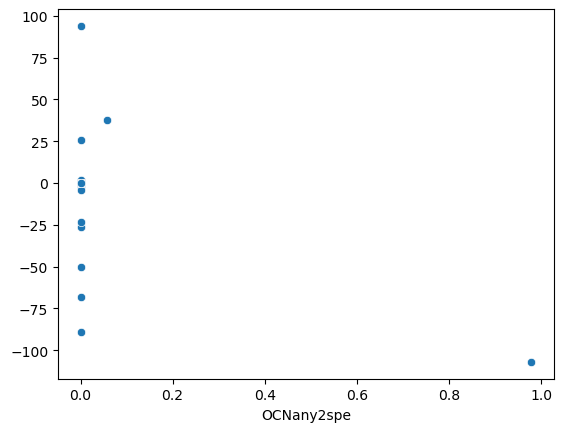

In [1264]:
sns.scatterplot(x=csubst_site['OCNany2spe'],
                y=csubst_site['aa_37_hydrophobicity'] - csubst_site['aa_37_anc_hydrophobicity'] )

<AxesSubplot:xlabel='OCNany2spe'>

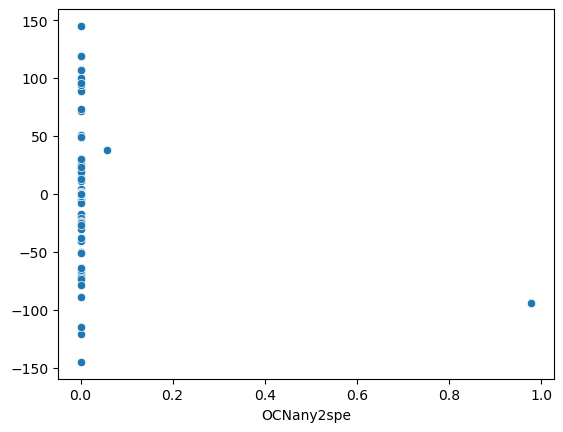

In [1268]:
sns.scatterplot(x=csubst_site['OCNany2spe'],
                y=csubst_site['aa_206_hydrophobicity'] - csubst_site['aa_206_anc_hydrophobicity'] )

In [1350]:
aa2hpb = csubst_site.groupby(['aa_206']).apply(lambda x: x['aa_206_hydrophobicity'].unique()[0]) #.value_counts().sort_index()

In [1357]:
all_temps = pd.concat([genome2temp.reindex(embedding_2d.index)['mean_temp'].dropna(),
                       internal_ancestral_states])
all_temps

GB_GCA_003148465.1    50.000000
GB_GCA_010730955.1    31.333333
RS_GCF_000006985.1    42.525029
RS_GCF_000007905.1    41.500000
RS_GCF_000009905.1    60.000000
                        ...    
Node747               32.576299
Node748               32.341724
Node749               31.863850
Node750               32.000585
Node751               29.468553
Length: 1504, dtype: float64

In [1371]:
plotdf = pd.DataFrame(columns=['temp', 'temp up', 'Max SASA diff'])
for node in ancseq_tree.traverse():
    if not node.is_root() and not node.up.is_root():
        key = f'{node.up.name} - {node.name}'
        plotdf.loc[key, 'temp'] = all_temps.loc[node.name]
        plotdf.loc[key, 'temp up'] = all_temps.loc[node.up.name] - all_temps.loc[node.name]
        plotdf.loc[key, 'Max SASA diff'] = aa2hpb.loc[position_map.loc[node.up.name][1]] - aa2hpb.loc[position_map.loc[node.name][1]]

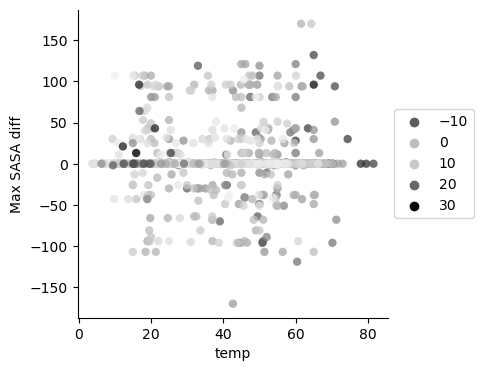

In [1396]:
fig, ax = plt.subplots(figsize=(4, 4))
cmap = sns.diverging_palette(359, 359, s=0, l=0, as_cmap=True)
norm = mpl.colors.TwoSlopeNorm(0, plotdf['temp up'].min(), plotdf['temp up'].max()) 
sns.scatterplot(data=plotdf.sort_values('temp up'),
                x='temp',
                y='Max SASA diff',
                hue='temp up',
                linewidth=0, alpha=0.75,
                palette= sns.diverging_palette(359, 359, s=0, l=0, as_cmap=True)#plotdf['temp up'].apply(lambda x: cmap(norm(x)))
                )

lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

sns.despine()

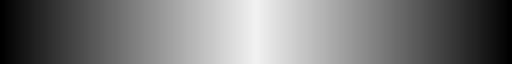

In [1384]:
cmap = sns.diverging_palette(359, 359, s=0, l=0, as_cmap=True)

In [1378]:
tree2name.loc[[str(s) for s in clades of ]]

,temp,temp diff,Max SASA diff,temp up
Node2 - Node3,44.847835,NaN,96.0,-1.010081
Node2 - RS_GCF_002973605.1,16.75,NaN,96.0,27.087754
Node635 - Node636,40.668227,NaN,96.0,1.714401
Node635 - RS_GCF_008838325.1,52.0,NaN,-11.0,-9.617372
Node3 - Node4,46.566464,NaN,-96.0,-1.718629
...,...,...,...,...
Node367 - RS_GCF_000429825.1,32.5,NaN,0.0,5.904381
Node203 - RS_GCF_005871205.1,25.0,NaN,0.0,5.556241
Node203 - RS_GCF_007671655.1,35.0,NaN,-30.0,-4.443759
Node368 - RS_GCF_000378425.1,42.666667,NaN,89.0,-5.372904


In [1349]:
csubst_site.groupby(['aa_25']).apply(lambda x: x['aa_25_hydrophobicity'].unique()[0]) #.value_counts().sort_index()

aa_25
A    129.0
C    167.0
D    193.0
E    223.0
F    240.0
G    104.0
H    224.0
I    197.0
K    236.0
L    201.0
M    224.0
N    195.0
P    159.0
Q    225.0
R    274.0
S    155.0
T    172.0
V    174.0
Y    263.0
dtype: float64

In [1342]:
csubst_site

,codon_site_alignment,nuc_site_alignment,OCSany2any,OCSspe2any,OCSany2spe,OCSspe2spe,OCSany2dif,OCNany2any,OCNspe2any,OCNany2spe,...,aa_206,aa_25_anc,aa_37_anc,aa_206_anc,aa_25_hydrophobicity,aa_37_hydrophobicity,aa_206_hydrophobicity,aa_25_anc_hydrophobicity,aa_37_anc_hydrophobicity,aa_206_anc_hydrophobicity
0,1,1,0.0,0.0,0.0,0.0,0.0,0.0001,0.0,0.0,...,M,M,M,M,174.0,174.0,224.0,224.0,224.0,224.0
1,2,4,0.0,0.0,0.0,0.0,0.0,0.0001,0.0,0.0,...,K,H,E,Q,224.0,225.0,236.0,224.0,223.0,225.0
2,3,7,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,I,V,V,I,174.0,174.0,197.0,174.0,174.0,197.0
3,4,10,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,V,I,I,I,197.0,197.0,174.0,197.0,197.0,197.0
4,5,13,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,L,I,F,L,174.0,240.0,201.0,197.0,240.0,201.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,209,625,0.0,0.0,0.0,0.0,0.0,0.0016,0.0,0.0,...,R,T,A,A,174.0,129.0,274.0,172.0,129.0,129.0
209,210,628,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,I,A,A,I,129.0,129.0,197.0,129.0,129.0,197.0
210,211,631,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,V,L,L,L,201.0,201.0,174.0,201.0,201.0,201.0
211,212,634,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,N,R,G,R,223.0,104.0,195.0,274.0,104.0,274.0


In [1258]:
position_map.loc['RS_GCF_000820845.2']

(189, 'A')

In [1257]:
tree2name.loc['206']

'RS_GCF_000820845.2'

In [1282]:
clades_of_interest = np.unique(result[[c for c in result.columns if 'branch_id' in c]].values.flatten()) #.unique()

In [1283]:
# clades_of_interest = [25, 37, 206]

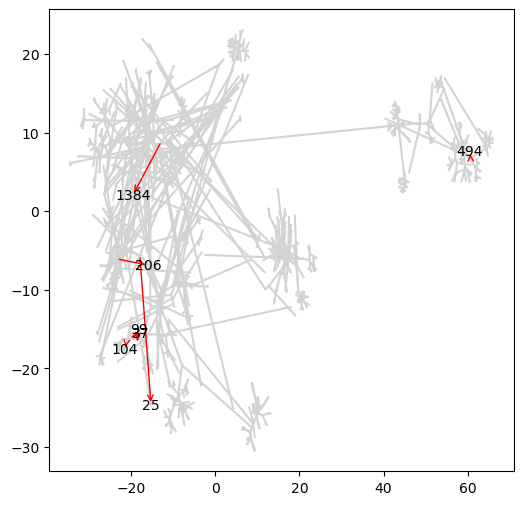

In [1284]:
fig, ax = plt.subplots(figsize=(6,6))
for node in list(ancseq_tree.traverse(strategy='levelorder')):
    
    if not node.is_leaf():
        children = node.get_children()
        if node.name in embedding_2d.index:
            xy = embedding_2d.loc[node.name, :].values
            
            for c in children:
                if c.name in embedding_2d.index:

                    xy_c = embedding_2d.loc[c.name, :].values
                    
                    if int(tree_name_map.loc[c.name]) in clades_of_interest:
                        
                        color = 'red'
                        zorder=1
                        ax.annotate(text=tree_name_map.loc[c.name],
                                    xy=xy_c, ha='center', va='center')
                        
                        ax.annotate(text='', 
                                    xytext=xy, # from
                                    xy=xy_c, # to
                                    arrowprops=dict(
                                        arrowstyle="->", 
                                        color=color,
                                        linewidth=1
                                    ),
                                    zorder=zorder, ha='center', va='center')

                    else:
                        color='lightgray'
                        zorder=0
                        plt.plot([xy[0], xy_c[0]], [xy[1], xy_c[1]], color=color, zorder=zorder)
                    
# ax.set_xlim(-22, -18)

In [1321]:
result

,branch_id_1,branch_id_2,branch_id_3,dist_bl,dist_node_num,branch_num_fg,branch_num_fg_stem,branch_num_mg,is_fg,is_mf,...,ECNspe2spe,ECSany2any,ECSany2dif,ECSany2spe,ECSdif2any,ECSdif2dif,ECSdif2spe,ECSspe2any,ECSspe2dif,ECSspe2spe
0,25,37,206,9.5062,44.0,3,3,0,Y,N,...,0.0344,2.2293,2.0288,0.2005,1.9046,1.7970,0.1076,0.3247,0.2318,0.0929
1,25,37,494,9.5062,44.0,3,3,0,Y,N,...,0.0145,1.0053,0.9106,0.0947,0.8577,0.8101,0.0477,0.1475,0.1005,0.0470
2,37,206,494,9.3073,44.0,3,3,0,Y,N,...,0.0215,1.0146,0.9209,0.0937,0.8609,0.8215,0.0394,0.1537,0.0994,0.0542
3,99,104,1384,4.5317,25.0,3,3,0,Y,N,...,0.0080,1.0741,1.0016,0.0725,1.0071,0.9535,0.0536,0.0670,0.0482,0.0189


In [955]:
# clades_of_interest = [25, 37, 206]

In [1242]:
row_pairs = [(node.name.split('|')[0], node.up.name.split('|')[0]) for node in csubst_tree.traverse() if node.up is not None and (node.name.split('|')[0] in embedding_2d.index) and (node.up.name.split('|')[0] in embedding_2d.index)]

In [1244]:
row_pairs

[('Node635', 'Node1'),
 ('Node2', 'Node1'),
 ('Node636', 'Node635'),
 ('RS_GCF_008838325.1', 'Node635'),
 ('RS_GCF_002973605.1', 'Node2'),
 ('Node3', 'Node2'),
 ('Node637', 'Node636'),
 ('Node717', 'Node636'),
 ('Node588', 'Node3'),
 ('Node4', 'Node3'),
 ('Node638', 'Node637'),
 ('Node676', 'Node637'),
 ('Node718', 'Node717'),
 ('Node724', 'Node717'),
 ('Node589', 'Node588'),
 ('Node621', 'Node588'),
 ('Node582', 'Node4'),
 ('Node5', 'Node4'),
 ('Node639', 'Node638'),
 ('Node665', 'Node638'),
 ('Node677', 'Node676'),
 ('RS_GCF_003386795.1', 'Node676'),
 ('Node719', 'Node718'),
 ('RS_GCF_001517975.1', 'Node718'),
 ('Node725', 'Node724'),
 ('Node750', 'Node724'),
 ('Node590', 'Node589'),
 ('RS_GCF_000092425.1', 'Node589'),
 ('RS_GCF_000316515.1', 'Node621'),
 ('Node622', 'Node621'),
 ('Node583', 'Node582'),
 ('Node586', 'Node582'),
 ('Node581', 'Node5'),
 ('Node6', 'Node5'),
 ('Node640', 'Node639'),
 ('Node663', 'Node639'),
 ('Node666', 'Node665'),
 ('Node674', 'Node665'),
 ('Node678', '

In [1243]:
# Compute vectors
vectors = np.array([tsne_plotdf.loc[end].values - tsne_plotdf.loc[start].values for start, end in row_pairs])

unit_vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
cosine_similarity = unit_vectors @ unit_vectors.T

# Extract upper triangle (excluding diagonal)
i_upper = np.triu_indices_from(cosine_similarity, k=1)
non_redundant = cosine_similarity[i_upper]

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(non_redundant.flatten(), ax=ax)

# Compute vectors
row_pairs2 = [p for p in row_pairs if any(int(tree_name_map.loc[_p]) in clades_of_interest for _p in p)]
vectors = np.array([tsne_plotdf.loc[end].values - tsne_plotdf.loc[start].values for start, end in row_pairs2])

unit_vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
cosine_similarity = unit_vectors @ unit_vectors.T

# Extract upper triangle (excluding diagonal)
i_upper = np.triu_indices_from(cosine_similarity, k=1)
non_redundant = cosine_similarity[i_upper]
# sns.histplot(non_redundant, ax=ax)
# for point in non_redundant.flatten():
#     ax.axvline(point, color='r', linewidth=1)
# ax.set_yscale('log')

KeyError: 'Node1'

The palette list has more values (18) than needed (14), which may not be intended.


Node594
Node595
Node597
Node138
Node204
Node335
Node344


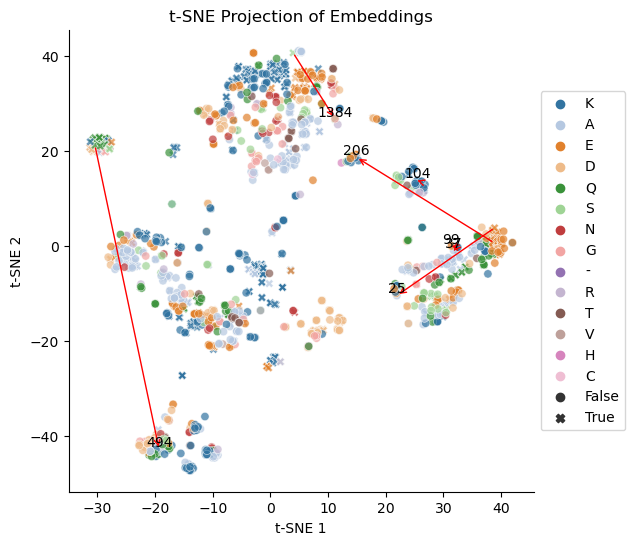

In [958]:
# Plot
fig, ax = plt.subplots(figsize=(6,6))
# clades_plus_parents = ['RS_GCF_000021685.1', 'RS_GCF_000091545.1', 'RS_GCF_000820845.2',
#                         'Node594',
#                         'Node335',
#                         'Node344']

# cmap = mpl.colormaps['gist_rainbow']
# norm = mpl.colors.Normalize(genome2temp['mean_temp'].min(), genome2temp['mean_temp'].max())
sns.scatterplot(x=embedding_2d['dim1'], 
            y=embedding_2d['dim2'], 
            alpha=0.7, 
            hue=position_map.apply(lambda x: x[1]),
            palette=[sns.desaturate(c, 0.75) for c in sns.color_palette('tab20', 18)], 
                hue_order=position_map.apply(lambda x: x[1]).value_counts().index,
                style=position_map.index.to_series().apply(lambda x: "Node" in x))

lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)) #genome2temp.reindex(tsne_index)['mean_temp'].apply(lambda x: cmap(norm(x))).fillna('k').values)

# fig, ax = plt.subplots(figsize=(6,6))
for node in list(ancseq_tree.traverse(strategy='levelorder')):
    
    if not node.is_leaf():
        children = node.get_children()
        if node.name in embedding_2d.index:
            xy = embedding_2d.loc[node.name, :].values
            
            for c in children:
                if c.name in embedding_2d.index:
                   

                    xy_c = embedding_2d.loc[c.name, :].values
                    
                    if int(tree_name_map.loc[c.name]) in clades_of_interest:
                        print(node.name)
                        color = 'red'
                        zorder=1
                        ax.annotate(text=tree_name_map.loc[c.name],
                                    xy=xy_c, ha='center', va='bottom')
                        
                        ax.annotate(text='', 
                                    xy=xy_c, 
                                    xytext=xy,
                                        arrowprops=dict(
                                            arrowstyle="->", 
                                            color=color,
                                            linewidth=1
                                        ),
                                    zorder=zorder)

                    # else:
                    #     color='lightgray'
                    #     zorder=0
                    #     plt.plot([xy[0], xy_c[0]], [xy[1], xy_c[1]], color=color, zorder=zorder)

# ax.set_xlim(-50, 50)
# ax.get_legend().remove()
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection of Embeddings")
sns.despine()
plt.show()

In [974]:
from scipy.spatial import ConvexHull

In [975]:
levels = pd.Series()
for node in ancseq_tree.traverse():
    levels.loc[node.name] = node.get_distance(ancseq_tree, node, topology_only=True)
    

The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.


In [981]:
levels

Node1                  0.0
Node2                  1.0
Node635                1.0
RS_GCF_000184345.1     1.0
Node3                  2.0
                      ... 
RS_GCF_000429825.1    45.0
RS_GCF_005871205.1    46.0
RS_GCF_007671655.1    46.0
RS_GCF_000378425.1    46.0
RS_GCF_003386235.1    46.0
Length: 1504, dtype: float64

In [1001]:
level_slices = pd.cut(levels, np.linspace(-0.1, levels.max(), 10))

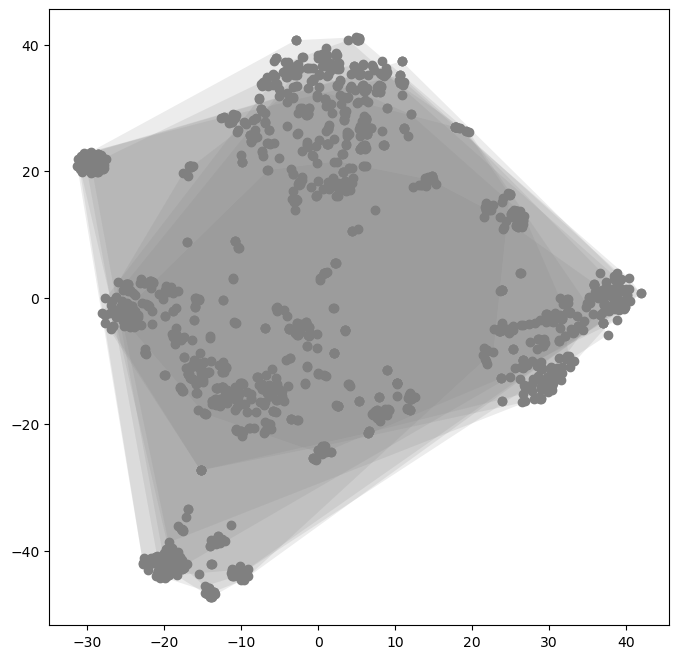

In [1004]:
fig, ax = plt.subplots(figsize=(8,8))
for _slice in level_slices.unique():
    nodes_at_level = [n for n in levels[(levels > _slice.left) & (levels < _slice.right)].index if n in embedding_2d.index]
    if len(nodes_at_level) > 2:
        points = embedding_2d.loc[nodes_at_level, :].values
        hull = ConvexHull(points)
        plt.scatter(points[:, 0], points[:, 1], color='gray', zorder=0)
        
        # Plot the convex hull
        # for simplex in hull.simplices:
            # plt.plot(points[simplex, 0], points[simplex, 1], 'white')
        
        plt.fill(points[hull.vertices,0], points[hull.vertices,1], 'gray', alpha=0.15, zorder=1)
        

In [948]:
postorder = pd.Series(dict((node.name, i) for i, node in enumerate(ancseq_tree.traverse(strategy='postorder'))))

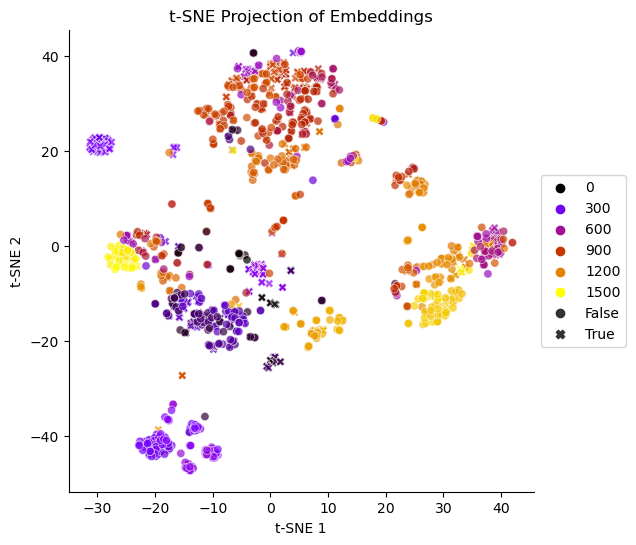

In [959]:
# Plot
fig, ax = plt.subplots(figsize=(6,6))
# clades_plus_parents = ['RS_GCF_000021685.1', 'RS_GCF_000091545.1', 'RS_GCF_000820845.2',
#                         'Node594',
#                         'Node335',
#                         'Node344']

cmap = mpl.colormaps['gist_rainbow']
norm = mpl.colors.Normalize(genome2temp['mean_temp'].min(), genome2temp['mean_temp'].max())
sns.scatterplot(x=embedding_2d['dim1'], 
            y=embedding_2d['dim2'], 
            alpha=0.7, 
            hue=postorder,
                palette='gnuplot',
                style=position_map.index.to_series().apply(lambda x: "Node" in x))

lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)) #genome2temp.reindex(tsne_index)['mean_temp'].apply(lambda x: cmap(norm(x))).fillna('k').values)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection of Embeddings")
sns.despine()
plt.show()

In [ ]:
tsne_plotdf.to_csv('./../data/proclam/embeddings/site_{}_embed.tsv', sep='\t'a)

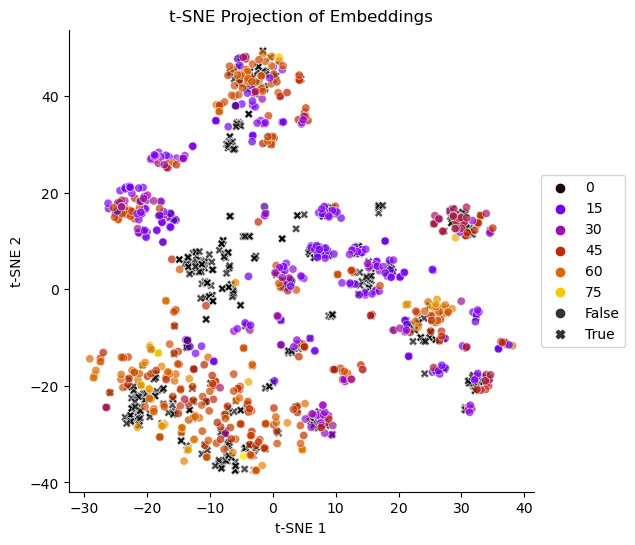

In [943]:
# Plot
fig, ax = plt.subplots(figsize=(6,6))
# clades_plus_parents = ['RS_GCF_000021685.1', 'RS_GCF_000091545.1', 'RS_GCF_000820845.2',
#                         'Node594',
#                         'Node335',
#                         'Node344']

cmap = mpl.colormaps['gist_rainbow']
norm = mpl.colors.Normalize(genome2temp['mean_temp'].min(), genome2temp['mean_temp'].max())
sns.scatterplot(x=embedding_2d['dim1'], 
            y=embedding_2d['dim2'], 
            alpha=0.7, 
            hue=genome2temp.reindex(position_map.index)['mean_temp'].fillna(-1),
                palette='gnuplot',
                style=position_map.index.to_series().apply(lambda x: "Node" in x))

lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)) #genome2temp.reindex(tsne_index)['mean_temp'].apply(lambda x: cmap(norm(x))).fillna('k').values)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection of Embeddings")
sns.despine()
plt.show()

## Perform regression on embedding

In [1404]:
leaf_embedding_only = tsne_plotdf[~tsne_plotdf.index.str.contains('Node')]

In [1405]:
X_train, X_test, y_train, y_test = train_test_split(leaf_embedding_only, genome2temp.loc[leaf_embedding_only.index, 'mean_temp'].values, test_size=0.2, )

In [1406]:
# # Normalize the target variable to compute KDE
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y_train.reshape(-1, 1))

# Estimate density of target variable using KDE
kde = KernelDensity(kernel='gaussian', bandwidth=0.2)
kde.fit(y_scaled)
log_density = kde.score_samples(y_scaled)
density = np.exp(log_density)

# Compute weights as inverse of density
weights = 1 / density

# Fit weighted linear regression
model = LinearRegression()
model.fit(X_train, y_train, sample_weight=weights)

# Model predictions
y_pred = model.predict(X_test)


In [1407]:
# Print results
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse}")

r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")

scores = cross_val_score(model, X_train, y_train, scoring='r2', cv=5)  # Example using R-squared
print(f"Cross-validated R-squared: {np.mean(scores):.2f} ± {np.std(scores):.2f}")

Model coefficients: [-4204.5825 -4401.232  -4090.415  -4497.294  -4615.59   -4202.8022
 -4416.7075 -4251.228  -4197.4277 -4485.143  -4535.183  -4376.876
 -4783.0776 -4058.107  -4771.368  -4129.968  -4567.6074 -4909.2607
 -4452.2056 -4622.1816 -4546.7173 -4724.6416 -4524.961  -4623.4805
 -4150.927  -4025.3125 -4129.362  -4652.5977 -4274.7207 -5126.4336
 -3968.17   -4511.334  -4509.4365 -3653.8289 -3901.6086 -3823.7888
 -4367.045  -4288.7866 -4255.902  -5107.212  -4152.0576 -4919.8555
 -4378.478  -4248.9883 -4690.2607 -4354.4624 -5081.2686 -3944.0327
 -4615.804  -5079.3184 -4878.987  -4541.0137 -4021.772  -4168.1855
 -4020.2258 -3994.9343 -4564.5137 -4588.584  -5091.428  -4648.74
 -4772.056  -4411.659  -6191.8486 -4561.331  -4489.567  -4338.9297
 -4851.066  -4527.522  -4964.833  -4673.638  -3803.9873 -4265.297
 -4393.027  -4566.7944 -4257.7056 -4716.8135 -4160.2407 -4592.9746
 -4582.168  -3872.5034 -3899.5376 -4318.0967 -4131.415  -4364.116
 -4351.807  -3931.4597 -4418.1426 -4112.451  -4

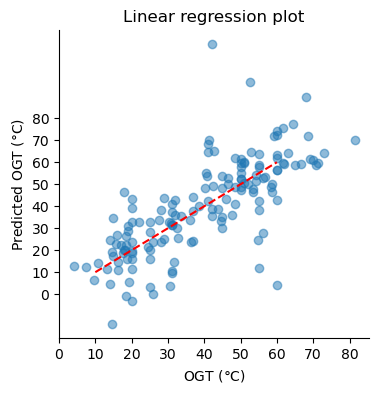

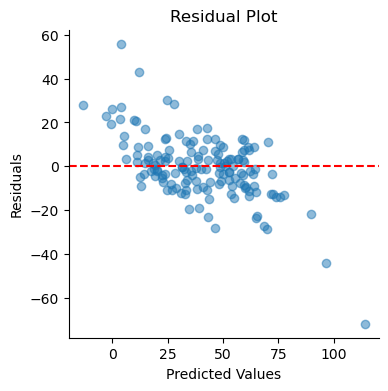

In [1408]:

# Plot test dataset
fig, ax = plt.subplots(figsize=(4,4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot((10, 60), (10, 60), color='red', linestyle='--')
plt.xlabel('OGT ($\degree$C)')
plt.ylabel('Predicted OGT ($\degree$C)')
plt.title('Linear regression plot')
ax.set_xticks(np.linspace(0, 80, 9))
ax.set_yticks(np.linspace(0, 80, 9))
sns.despine()

# plt.savefig('./../data/figures/linear_model_prediction_plot.png', dpi=400, bbox_inches='tight')
plt.show()
residuals = y_test - y_pred

# Plot residuals
fig, ax = plt.subplots(figsize=(4,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
sns.despine()

# plt.savefig('./../data/figures/linear_model_residual_plot.png', dpi=400, bbox_inches='tight')
plt.show()

In [243]:
parameters = {'n_estimators':[100, 500, 1000], 'learning_rate':[0.01, 0.1, 1]}
# reg = RandomForestRegressor(n_jobs=16)
reg = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.01)
# clf = GridSearchCV(reg, parameters, scoring='neg_root_mean_squared_error', n_jobs=16)
reg.fit(X=X_train, y=y_train)

GradientBoostingRegressor(learning_rate=0.01, n_estimators=1000)

In [244]:
r2_score(y_test, reg.predict(X_test))

0.6720557484296621

Text(0.5, 1.0, 'Regressor Performance')

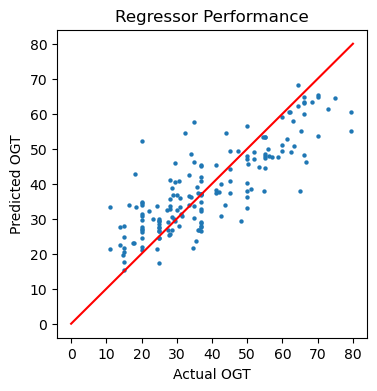

In [245]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x=y_test, y=reg.predict(X_test), linewidth=0, alpha=1, s=10)
plt.plot((0, 80), (0, 80), color='r')
yticks = ax.set_yticks(list(np.linspace(0, 80, 9)))
xticks = ax.set_xticks(list(np.linspace(0, 80, 9)))
ax.set_xlabel('Actual OGT')
ax.set_ylabel('Predicted OGT')
ax.set_title('Regressor Performance')

In [149]:
per_res_data[per_res_data['uid'].eq(g) & per_res_data['trim_res'].eq(position)]

,Position,Contacts at 4.5 Å,SASA,uid,lid,residue,alignment_res,trimmed,trim_res,trimmed_gapfrac
9756,22,13,10.768314,RS_GCF_000007905.1,False,A,611,False,200.0,0.002994


In [145]:
e[position-1, :].shape

(320,)

In [143]:
per_res_data[per_res_data['uid'].eq(g) & per_res_data['trim_res'].eq(position)]

,Position,Contacts at 4.5 Å,SASA,uid,lid,residue,alignment_res,trimmed,trim_res,trimmed_gapfrac
25114,20,13,58.95547,RS_GCF_000017805.1,False,E,611,False,200.0,0.002994


In [134]:
per_res_data[per_res_data['uid'].eq(g)]

,Position,Contacts at 4.5 Å,SASA,uid,lid,residue,alignment_res,trimmed,trim_res,trimmed_gapfrac
3766,0,11,30.257087,GB_GCA_003148465.1,False,M,496,False,179.0,0.041065
3767,1,13,31.862692,GB_GCA_003148465.1,False,K,522,False,181.0,0.018822
3768,2,17,0.000000,GB_GCA_003148465.1,False,L,592,False,182.0,0.014544
3769,3,15,0.084949,GB_GCA_003148465.1,False,I,594,False,183.0,0.013047
3770,4,16,1.285751,GB_GCA_003148465.1,False,F,595,False,184.0,0.012298
...,...,...,...,...,...,...,...,...,...,...
3976,210,9,37.710525,GB_GCA_003148465.1,False,G,1424,False,409.0,0.389263
3977,211,13,18.411183,GB_GCA_003148465.1,False,V,1425,False,410.0,0.666667
3978,212,8,65.521242,GB_GCA_003148465.1,False,S,1426,False,411.0,0.896375
3979,213,6,128.308681,GB_GCA_003148465.1,False,D,1489,False,413.0,0.533954


In [166]:
per_res_data[(per_res_data['Position'] > 200) & (per_res_data['Position'] < 205)]

,Position,Contacts at 4.5 Å,SASA,uid,lid,residue,alignment_res,trimmed,trim_res,trimmed_gapfrac
388,201,10,84.466996,GB_GCA_000016765.1,False,M,1223,False,395.0,0.016255
389,202,7,75.519988,GB_GCA_000016765.1,False,A,1236,False,396.0,0.003422
390,203,9,84.862294,GB_GCA_000016765.1,False,D,1248,False,397.0,0.001176
391,204,15,4.417331,GB_GCA_000016765.1,False,V,1249,False,398.0,0.001176
591,201,7,75.006481,GB_GCA_000242235.1,False,G,972,False,376.0,0.007593
...,...,...,...,...,...,...,...,...,...,...
1975015,204,16,2.548460,RS_GCF_910593845.1,False,V,1249,False,398.0,0.001176
1975227,201,10,88.696002,RS_GCF_907163265.1,False,Q,1188,False,392.0,0.005882
1975228,202,7,66.884658,RS_GCF_907163265.1,False,G,1215,False,393.0,0.003743
1975229,203,7,147.587719,RS_GCF_907163265.1,False,R,1217,False,394.0,0.002353


In [82]:
files = glob.glob('/data/mhoffert/realmichaelhoffert/protein_language_model/files/all_adks_out/esm_outputs/*.pt')

In [86]:
torch.load(files[0]).keys() #['representations'][6].shape

dict_keys(['label', 'model_info', 'logits', 'sequence', 'representations', 'mean_representations'])

In [ ]:
for f in files:
    pytorch.load(f)

## Ensemble model

In [1421]:
embeddings = {}
tsne_indeces = {}
for position in range(len(trim_aln_df.columns)):
    
    display(position)
    clear_output(wait=True)
    
    embeddings[position] = []
    tsne_indeces[position] = []
    
    position_map = get_og_locs(aln_df, trim_aln_df, position)
    tsne_index = []
    check_lengths = []
    
    for i, g in enumerate(position_map.index):
        
        # display('position')
        # clear_output(wait=True)
        
        potential_proteins = [p for p in dataset.proteins if g == p.label.split(' ')[0]]
        check_lengths.append(len(potential_proteins))
        _protein = potential_proteins[0]

        e = _protein.get_embedding()
        loc = position_map.loc[g][0]
        res = position_map.loc[g][1]

        # try:
        if 0 < loc <= e.shape[0]:
            # print(loc, e.shape)

            embeddings[position].append(e[loc+1, :])
            residues.append(_protein.sequence[loc])

            # check for niche error where the alignment excludes a fragment
            row = aln_df.loc[g, :]
            row_str = ''.join(list(row[~row.eq('-')].values))

            try:
                assert len(_protein.sequence) == len(row_str)

            except AssertionError:
                # niche error means some things might have part of the sequence excluded in the alignment
                # if it has no homolog in leaf sequences
                # see mafft alignment 
                aln_row, aln_protein, score, start, end = align_fast(row_str, _protein.sequence)

                # this test must pass
                assert aln_row[loc] == aln_protein[loc]

            tsne_indeces[position].append(g)

        else:
            print('Site is a gap', loc, e.shape)
# print(len(embeddings), len(tsne_index))

Site retrieved: 318
Site is a gap -1 (216, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (214, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (184, 320)
Site is a gap -1 (212, 320)
Site is a gap -1 (213, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (184, 320)
Site is a gap -1 (197, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (190, 320)
Site is a gap -1 (214, 320)
Site is a gap -1 (186, 320)
Site is a gap -1 (205, 320)
Site is a gap -1 (216, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (214, 320)
Site is a gap -1 (213, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (216, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (214, 320)
Site is a gap -1 (218, 320)
Site is a gap -1 (187, 320)
Site is a gap -1 (218, 320)
Site is a gap -1 (215, 320)
Site is a gap -1 (218, 320)
Site is a gap -1 (217, 320)
Site is a gap -1 (215, 320)


In [311]:
example_genomes = plotdf.groupby('bin').apply(lambda x: x.sample(np.min([100, len(x)])))['uid'].unique()
positions = per_res_data[per_res_data['trimmed_gapfrac'] < 0.10]['trim_res'].unique()
for position in positions:
    if not position in embeddings.keys():
        embeddings[position] = []
        residues[position] = []

        # print(len(example_genomes))
        for i, g in enumerate(example_genomes):
            # print(g)
            if i  % 10 == 0:
                display(i / n)
                clear_output(wait=True)
            _protein = [p for p in dataset.proteins if g in p.label][0]
            try:
                loc = per_res_data[per_res_data['uid'].eq(g) & per_res_data['trim_res'].eq(position)]['Position'].values[0]
                e = _protein.get_embedding()
                # print(e.shape, len(_protein.sequence), per_res_data[per_res_data['uid'].eq(g)].shape)
                embeddings[position].append(e[loc, :])
                residues[position].append(_protein.sequence[loc])

            except IndexError:
                print(f"Position {position} failed")
                del embeddings[position]
                del residues[position]
                break
    

# pd.DataFrame.from_dict(dict((p.label, p.get_embedding()) for p in dataset.proteins[:5]))

Position 408.0 failed


In [1413]:
embeddings.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212])

In [1440]:
models = []

# X_train, X_test, 
train_ind, test_ind = train_test_split(leaf_embedding_only.index, test_size=0.2, )
# y_train = genome2temp.loc[train_ind, 'mean_temp'].values
# y_test = genome2temp.loc[test_ind, 'mean_temp'].values



X_trains = []
y_trains = []
X_tests = []
y_tests = []

model_labels = []

for p in embeddings.keys():
    
    display(p)
    clear_output(wait=True)
    
    model_labels.append(p)
    # try:
    tsne_plotdf = pd.DataFrame(embeddings[p], index=tsne_indeces[p])

    X_train = tsne_plotdf.loc[list(set(train_ind).intersection(set(tsne_plotdf.index))), :]
    X_trains.append(X_train)
    X_test = tsne_plotdf.loc[list(set(test_ind).intersection(set(tsne_plotdf.index))), :]
    X_tests.append(tsne_plotdf.loc[list(set(test_ind).intersection(set(tsne_plotdf.index))), :])

    # Fit weighted linear regression
    y_train = genome2temp.loc[list(set(train_ind).intersection(set(tsne_plotdf.index))), 'mean_temp']
    y_test = genome2temp.loc[list(set(test_ind).intersection(set(tsne_plotdf.index))), 'mean_temp']
    
    y_trains.append(y_train)
    y_tests.append(y_test)
    
    model = LinearRegression()
    
    # # Normalize the target variable to compute KDE
    scaler = StandardScaler()
    y_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))

    # Estimate density of target variable using KDE
    kde = KernelDensity(kernel='gaussian', bandwidth=0.2)
    kde.fit(y_scaled)
    log_density = kde.score_samples(y_scaled)
    density = np.exp(log_density)

    # Compute weights as inverse of density
    weights = 1 / density
    
    model.fit(X_train.values, y_train.values, sample_weight=weights)
    models.append(model)
        # print('success')
        
    # except ValueError:
    #     print('run was incomplete')
#     # Model predictions
#     y_pred = model.predict(X_test)


212

In [1428]:
# # # Normalize the target variable to compute KDE
# scaler = StandardScaler()
# y_scaled = scaler.fit_transform(y_train.reshape(-1, 1))

# # Estimate density of target variable using KDE
# kde = KernelDensity(kernel='gaussian', bandwidth=0.2)
# kde.fit(y_scaled)
# log_density = kde.score_samples(y_scaled)
# density = np.exp(log_density)

# # Compute weights as inverse of density
# weights = 1 / density

# # Fit weighted linear regression
# model = LinearRegression()
# model.fit(X_train, y_train, sample_weight=weights)

# # Model predictions
# y_pred = model.predict(X_test)


In [1435]:
y_tests[0].shape

(32,)

In [1436]:
X_tests[0].shape

(32, 320)

In [1448]:
refined_models, refined_tests = [], []
model_scores = {}
for i, (model, X, y) in enumerate(zip(models, X_tests, y_tests)):
    model_scores[model_labels[i]] = r2_score(y, model.predict(X))
    if r2_score(y, model.predict(X)) > 0.25:
        refined_models.append(model)
        refined_tests.append(X)
    

In [1443]:
def ensemble_predictions(models, X):
    """Average predictions from a list of models."""
    preds = pd.concat([pd.Series(data=model.predict(_X), index=_X.index) for model, _X in zip(models, X)], axis=1)
    return preds #np.mean(preds, axis=0)  # Averaged predictions

In [1446]:
ensemble_predictions(models, X_tests).mean(1)

RS_GCF_000426825.1    47.531094
RS_GCF_003231285.1    19.545685
RS_GCF_003219815.1    22.134836
RS_GCF_002204745.1    12.866863
RS_GCF_900111965.1    21.648449
                        ...    
RS_GCF_000007905.1    40.184940
RS_GCF_000018025.1    10.066654
RS_GCF_007827555.1    49.831261
RS_GCF_002924625.1    50.665836
RS_GCF_000195335.1    57.985893
Length: 151, dtype: float32

In [1447]:
preds = ensemble_predictions(models, X_tests).mean(1)
r2_score(genome2temp.loc[preds.index, 'mean_temp'], preds)

0.7905834162797942

In [1458]:
refined_preds = ensemble_predictions(refined_models, refined_tests).mean(1)
r2_score(genome2temp.loc[refined_preds.index, 'mean_temp'], refined_preds)
# refined_preds

0.802632215674999

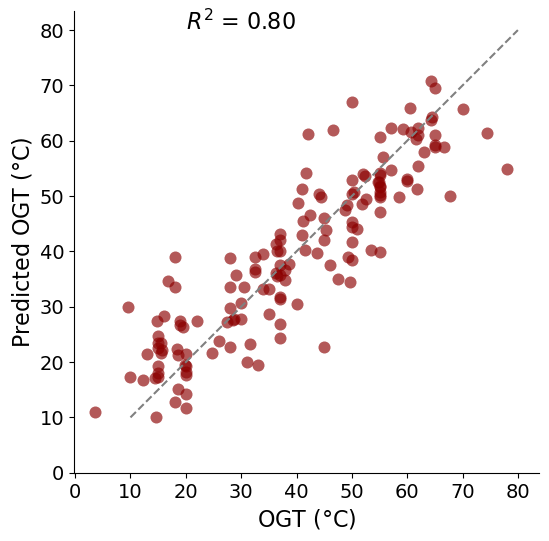

In [1466]:
fig, ax = plt.subplots(figsize=(6,6))
preds = ensemble_predictions(models, X_tests).mean(1)
sns.scatterplot(x=genome2temp.loc[preds.index, 'mean_temp'], alpha=0.65,
                y=preds, linewidth=0, s=75, color='darkred')

plt.plot((10, 80), (10, 80), color='gray', linestyle='--')

r2 = r2_score(genome2temp.loc[refined_preds.index, 'mean_temp'], refined_preds)
ax.annotate(f'$R^2$ = {r2:.2f}', (20, 80), fontsize=16)

plt.tick_params(labelsize=14)
plt.xlabel('OGT ($\degree$C)', fontsize=16)
plt.ylabel('Predicted OGT ($\degree$C)', fontsize=16)
ax.set_xticks(np.linspace(0, 80, 9))
ax.set_yticks(np.linspace(0, 80, 9))

sns.despine()

plt.savefig('./../../data/figures/ESM2_linear.png', dpi=400, bbox_inches='tight')

<AxesSubplot:ylabel='Count'>

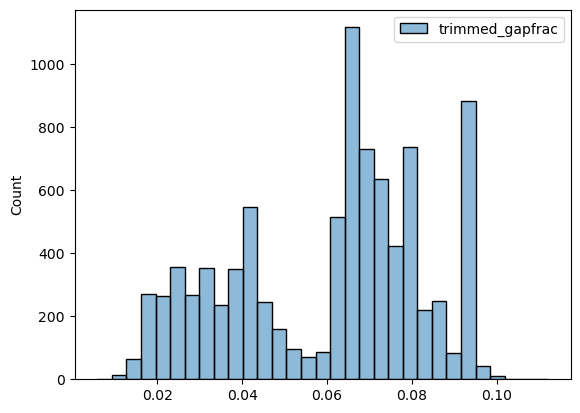

In [343]:
per_seq_gapfrac = per_res_data.groupby(['uid']).agg({'trimmed_gapfrac':'mean'})
sns.histplot(per_seq_gapfrac[per_seq_gapfrac['trimmed_gapfrac'] < 0.12].index)

In [346]:
filtered_seqs = per_seq_gapfrac[per_seq_gapfrac['trimmed_gapfrac'] < 0.12].index

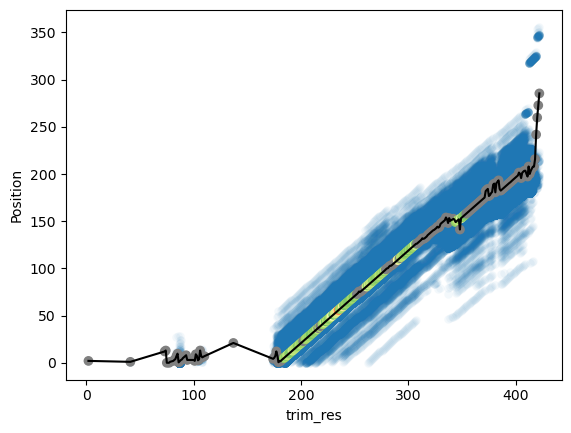

In [360]:
trim2pos = per_res_data[per_res_data['uid'].isin(filtered_seqs)].groupby('trim_res').agg({'Position':'mean'}).reset_index()
sns.scatterplot(data=per_res_data[per_res_data['uid'].isin(filtered_seqs)], x='trim_res', y='Position', linewidth=0, alpha=0.05)
plt.plot(trim2pos['trim_res'], trim2pos['Position'], color='k')
cmap = mpl.colormaps['RdYlGn']
norm = mpl.colors.Normalize(-1, 1)
plt.scatter(trim2pos['trim_res'], trim2pos['Position'], 
            c=trim2pos['trim_res'].apply(lambda x: cmap(norm(model_scores[x])) if x in model_scores.keys() else 'gray').values
           )